<div style="text-align: center;">

# Sustainability Aware Asset Management  
# Portfolio Allocation with a Carbon Objective  

<br>

**Course:** Sustainability Aware Asset Management<br>
**Instructor:** Professor Eric Jondeau<br> 
**Academic Year:** 2025–2026<br>  

<br>

**Group Members**  
Matteo Piras<br>
Tomas Papuga<br> 
Marco D'Amico<br>
Roberto Berardi<br> 

<br>

**Submission Date:** May 2026  

</div>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display


## 1. Data — Report Section 2

The investment universe is defined from a static dataset covering firm-level characteristics. Only firms classified as Emerging Markets (EM) are retained. A helper function standardises all Datastream Excel exports by removing error-flagged entries (`$$ER`), transposing the data so that firms are columns and dates are the index, and parsing the index as either monthly dates or integer years depending on the data type.

In [3]:
static_df = pd.read_excel('Data_2026/Static_2025.xlsx')
static_df['ISIN'] = static_df['ISIN'].astype(str).str.strip()

em_firms       = static_df[static_df['Region'] == 'EM'].copy()
valid_em_isins = em_firms['ISIN'].unique().tolist()

def load_and_transpose(filepath, is_monthly=False):
    df = pd.read_excel(filepath)
    df = df[~df['ISIN'].astype(str).str.contains(r'\$\$ER', na=False)]
    df['ISIN'] = df['ISIN'].astype(str).str.strip()
    df.set_index('ISIN', inplace=True)

    if 'NAME' in df.columns:
        df.drop(columns=['NAME'], inplace=True)

    df_t = df.T
    df_t = df_t.apply(pd.to_numeric, errors='coerce')

    if is_monthly:
        df_t.index = pd.to_datetime(df_t.index)
    else:
        df_t.index = df_t.index.astype(int)
    return df_t

print("Static data loaded and EM firms identified.")

Static data loaded and EM firms identified.


## 2. Return Index Processing and Delisting Logic — Report Sections 2.1–2.3

Monthly total return indices (RI) are loaded in USD and filtered to retain only EM firms. Prices below $0.50 are treated as missing to avoid distortions from penny stocks. Forward-filling bridges legitimate data gaps without masking firm disappearance — the last valid date is recorded before filling so that delisting events are preserved. When a firm's price series ends before the sample end, a -100% return is assigned in the first month after disappearance, followed by NaN for all subsequent periods to avoid stale-price bias in later calculations.

In [4]:
ri_monthly = load_and_transpose('Data_2026/DS_RI_T_USD_M_2025.xlsx', is_monthly=True)
ri_em      = ri_monthly[[isin for isin in valid_em_isins if isin in ri_monthly.columns]].copy()

# Prices below 0.5 are treated as missing to avoid distortions from penny stocks
ri_em[ri_em < 0.5] = np.nan

# Last valid date is captured before forward-filling to preserve delisting information
real_last_valid_dates = ri_em.apply(lambda col: col.last_valid_index())

ri_em_filled = ri_em.ffill()
returns_em   = ri_em_filled.pct_change(fill_method=None)

for isin in returns_em.columns:
    last_date = real_last_valid_dates[isin]
    if pd.notna(last_date):
        last_pos = returns_em.index.get_loc(last_date)
        if last_pos < len(returns_em) - 1:
            returns_em.iloc[last_pos + 1, returns_em.columns.get_loc(isin)] = -1.0
            if last_pos + 1 < len(returns_em) - 1:
                returns_em.iloc[last_pos + 2:, returns_em.columns.get_loc(isin)] = np.nan
    else:
        returns_em[isin] = np.nan

## 3. Carbon Emissions Data — Report Section 2.4

Scope 1 and Scope 2 annual carbon emissions are loaded and filtered to the EM universe. Forward-filling is applied to bridge years where firms did not report emissions data. Firms with no data at all across returns or emissions are dropped entirely from all matrices before any portfolio construction begins.

In [5]:
scope1_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_1_Y_2025.xlsx', is_monthly=False)
scope2_em = load_and_transpose('Data_2026/DS_CO2_SCOPE_2_Y_2025.xlsx', is_monthly=False)

# ffill() propagates only forward in time so NaN values at the start of a firm's history
# remain NaN. This prevents any backward imputation of missing early emissions data.
scope1_em = scope1_em[[isin for isin in valid_em_isins if isin in scope1_em.columns]].copy().ffill()
scope2_em = scope2_em[[isin for isin in valid_em_isins if isin in scope2_em.columns]].copy().ffill()

returns_em.dropna(how='all', axis=1, inplace=True)
scope1_em.dropna(how='all', axis=1, inplace=True)
scope2_em.dropna(how='all', axis=1, inplace=True)

print("Data Validation Overview:")
print(f"- Returns Matrix: {returns_em.shape[0]} months, {returns_em.shape[1]} firms")
print(f"- Scope 1/2 Matrices: {scope1_em.shape[0]} years")
display(returns_em.head())

Data Validation Overview:
- Returns Matrix: 314 months, 668 firms
- Scope 1/2 Matrices: 27 years


ISIN,ARALUA010258,ARP125991090,ARSIDE010029,BMG211591018,BRABEVACNOR1,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4,...,ZAE000117321,ZAE000127148,ZAE000134961,ZAE000170049,ZAE000179420,ZAE000191342,ZAE000255915,ZAE000298253,ZAE000302618,ZAE000322095
1999-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-31,0.176511,-0.051861,-0.004877,NaN,-0.044175,-0.067245,0.023986,-0.249634,0.011906,NaN,...,-0.115161,-0.049527,0.096965,0.067794,0.205596,0.099568,-0.080722,0.125341,0.021174,-0.114179
2000-02-29,0.050002,0.178923,0.039543,NaN,-0.045539,-0.036328,-0.107794,0.005452,0.043492,NaN,...,-0.037800,-0.100608,-0.326248,0.028928,-0.053481,-0.084315,-0.062844,-0.181598,0.018379,-0.023150
2000-03-31,-0.023552,-0.105072,-0.002113,NaN,0.313941,-0.130625,0.152061,0.014002,0.002361,NaN,...,-0.067887,-0.034040,-0.044066,-0.176088,-0.126866,0.073915,-0.054382,-0.038462,-0.142989,-0.104274
2000-04-28,-0.016173,-0.161842,-0.071188,NaN,-0.001350,-0.077311,-0.108617,-0.032966,-0.020143,NaN,...,-0.034586,-0.042240,-0.172342,-0.129131,-0.035409,-0.208833,-0.030503,-0.224615,-0.095572,0.003496


The output confirms the dimensions of the returns matrix and the number of years covered by the emissions data. The head of the returns matrix provides a first look at the data structure before any portfolio construction.

## 4. Dynamic Universe Construction — Report Section 2.5

For each estimation year $Y$ from 2009 to 2024, the eligible investment universe is identified using a rolling 10-year window of data. A firm is included in the holding year $Y+1$ universe only if it satisfies three conditions simultaneously: it has a valid price above $0.50$ at the end of year $Y$, it has at least 60 months of non-missing returns with no more than 50% zero-return months to filter out illiquid assets, and it has both Scope 1 and Scope 2 emissions data available for year $Y$.

In [6]:
valid_investment_sets = {}
estimation_years      = range(2009, 2025)

for Y in estimation_years:
    start_date     = f"{Y-9}-01-01"
    end_date       = f"{Y}-12-31"
    window_returns = returns_em.loc[start_date:end_date]
    window_prices  = ri_em.loc[start_date:end_date]

    valid_isins_for_year = []

    for isin in returns_em.columns:
        if pd.isna(window_prices[isin].iloc[-1]):
            continue

        total_valid_months = window_returns[isin].notna().sum()
        if total_valid_months < 60:
            continue

        if (window_returns[isin] == 0.0).sum() / 120 > 0.5:
            continue

        if Y in scope1_em.index and Y in scope2_em.index:
            if isin in scope1_em.columns and isin in scope2_em.columns:
                if not pd.isna(scope1_em.loc[Y, isin]) and not pd.isna(scope2_em.loc[Y, isin]):
                    valid_isins_for_year.append(isin)

    valid_investment_sets[Y + 1] = valid_isins_for_year
    print(f"Holding Year {Y+1}: {len(valid_isins_for_year)} firms identified.")

print("Investment universes constructed successfully.")

Holding Year 2010: 64 firms identified.
Holding Year 2011: 153 firms identified.
Holding Year 2012: 190 firms identified.
Holding Year 2013: 224 firms identified.
Holding Year 2014: 245 firms identified.
Holding Year 2015: 266 firms identified.
Holding Year 2016: 296 firms identified.
Holding Year 2017: 334 firms identified.
Holding Year 2018: 380 firms identified.
Holding Year 2019: 415 firms identified.
Holding Year 2020: 463 firms identified.
Holding Year 2021: 503 firms identified.
Holding Year 2022: 540 firms identified.
Holding Year 2023: 569 firms identified.
Holding Year 2024: 578 firms identified.
Holding Year 2025: 566 firms identified.
Investment universes constructed successfully.


Each row confirms the number of eligible firms identified for each holding year. The universe size varies across years reflecting changes in data availability and the liquidity filter.

## 5. Expected Returns and Covariance Matrices — Report Section 3.1

For each holding year $Y+1$, expected returns and the covariance matrix are estimated over the preceding 10-year window using the following formulas, where $\tau$ denotes the number of monthly observations (120) and missing returns are replaced by zero before computation:

$$\hat{\mu}_Y = \frac{1}{\tau} \sum_{t=1}^{\tau} R_t \qquad \Sigma_Y = \frac{1}{\tau} \sum_{t=1}^{\tau} (R_t - \hat{\mu}_Y)'(R_t - \hat{\mu}_Y)$$

In [7]:
mu_estimates    = {}
sigma_estimates = {}
estimation_years = range(2009, 2025)

for Y in estimation_years:
    holding_year = Y + 1
    valid_isins  = valid_investment_sets[holding_year]

    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    start_date     = f"{Y-9}-01-01"
    end_date       = f"{Y}-12-31"
    window_returns = returns_em.loc[start_date:end_date, valid_isins].copy().fillna(0)

    tau     = window_returns.shape[0]
    mu_hat_Y = window_returns.sum(axis=0) / tau

    R          = window_returns.to_numpy()
    mu         = mu_hat_Y.to_numpy().reshape(1, -1)
    R_centered = R - mu
    Sigma_array = (R_centered.T @ R_centered) / tau

    Sigma_Y = pd.DataFrame(Sigma_array,
                           index=window_returns.columns,
                           columns=window_returns.columns)

    mu_estimates[holding_year]    = mu_hat_Y
    sigma_estimates[holding_year] = Sigma_Y

    print(f"Holding Year {holding_year}: {len(valid_isins)} firms, "
          f"tau={tau}, mu size={mu_hat_Y.shape[0]}, Sigma shape={Sigma_Y.shape}")

print("Expected returns and covariance matrices computed successfully.")

example_year = 2014
if example_year in mu_estimates and example_year in sigma_estimates:
    print(f"\nExample: Holding Year {example_year}")
    display(mu_estimates[example_year].head())
    display(sigma_estimates[example_year].iloc[:5, :5])

Holding Year 2010: 64 firms, tau=120, mu size=64, Sigma shape=(64, 64)
Holding Year 2011: 153 firms, tau=120, mu size=153, Sigma shape=(153, 153)
Holding Year 2012: 190 firms, tau=120, mu size=190, Sigma shape=(190, 190)
Holding Year 2013: 224 firms, tau=120, mu size=224, Sigma shape=(224, 224)
Holding Year 2014: 245 firms, tau=120, mu size=245, Sigma shape=(245, 245)
Holding Year 2015: 266 firms, tau=120, mu size=266, Sigma shape=(266, 266)
Holding Year 2016: 296 firms, tau=120, mu size=296, Sigma shape=(296, 296)
Holding Year 2017: 334 firms, tau=120, mu size=334, Sigma shape=(334, 334)
Holding Year 2018: 380 firms, tau=120, mu size=380, Sigma shape=(380, 380)
Holding Year 2019: 415 firms, tau=120, mu size=415, Sigma shape=(415, 415)
Holding Year 2020: 463 firms, tau=120, mu size=463, Sigma shape=(463, 463)
Holding Year 2021: 503 firms, tau=120, mu size=503, Sigma shape=(503, 503)
Holding Year 2022: 540 firms, tau=120, mu size=540, Sigma shape=(540, 540)
Holding Year 2023: 569 firms,

ISIN
BRBBASACNOR3    0.024255
BRBBDCACNPR8    0.022722
BRBRFSACNOR8    0.032435
BRBRKMACNPA4    0.015174
BRCESPACNPB4    0.011178
dtype: float64

ISIN,BRBBASACNOR3,BRBBDCACNPR8,BRBRFSACNOR8,BRBRKMACNPA4,BRCESPACNPB4
ISIN,,,,,
BRBBASACNOR3,0.015590,0.010866,0.008129,0.007731,0.006893
BRBBDCACNPR8,0.010866,0.012099,0.008446,0.007131,0.005413
BRBRFSACNOR8,0.008129,0.008446,0.014663,0.006491,0.005183
BRBRKMACNPA4,0.007731,0.007131,0.006491,0.019695,0.004748
BRCESPACNPB4,0.006893,0.005413,0.005183,0.004748,0.014449


Each row confirms the number of firms, the number of observations and the dimensions of the estimated matrices for each holding year. The example output for 2014 shows the first entries of the expected return vector and the top-left block of the covariance matrix.

## 6. Minimum Variance Portfolio — Report Sections 3.1–3.2

For each holding year, the minimum variance portfolio is constructed by solving the following quadratic program, subject to full investment and long-only constraints:

$$\min_{\alpha} \; \alpha' \Sigma_Y \alpha \qquad \text{s.t.} \quad \alpha' \mathbf{e} = 1, \quad \alpha_i \geq 0$$

The optimizer uses SLSQP. Once the optimal weights are obtained, the portfolio is held for 12 months with weight drift applied each month according to:

$$\alpha_{i,t+k} = \frac{\alpha_{i,t+k-1}(1 + R_{i,t+k})}{1 + R_{p,t+k}}$$

Performance is evaluated over the period January 2014 to December 2025 (144 months) using the Fama-French monthly risk-free rate to compute excess returns and the Sharpe ratio.

Holding Year 2010: Optimization and drift simulated.
Holding Year 2011: Optimization and drift simulated.
Holding Year 2012: Optimization and drift simulated.
Holding Year 2013: Optimization and drift simulated.
Holding Year 2014: Optimization and drift simulated.
Holding Year 2015: Optimization and drift simulated.
Holding Year 2016: Optimization and drift simulated.
Holding Year 2017: Optimization and drift simulated.
Holding Year 2018: Optimization and drift simulated.
Holding Year 2019: Optimization and drift simulated.
Holding Year 2020: Optimization and drift simulated.
Holding Year 2021: Optimization and drift simulated.
Holding Year 2022: Optimization and drift simulated.
Holding Year 2023: Optimization and drift simulated.
Holding Year 2024: Optimization and drift simulated.
Holding Year 2025: Optimization and drift simulated.
Final evaluated months: 144 (Expected: 144)


,Metric,Value
0,Annualized Average Return (μ_p),0.067202
1,Annualized Volatility (σ_p),0.104769
2,Annualized Risk-Free Rate,0.017475
3,Sharpe Ratio (SR_p),0.474640
4,Minimum Return,-0.075919
5,Maximum Return,0.121323


Final out-of-sample returns saved to 'Ex_Post_Returns_Simple_MV.xlsx'


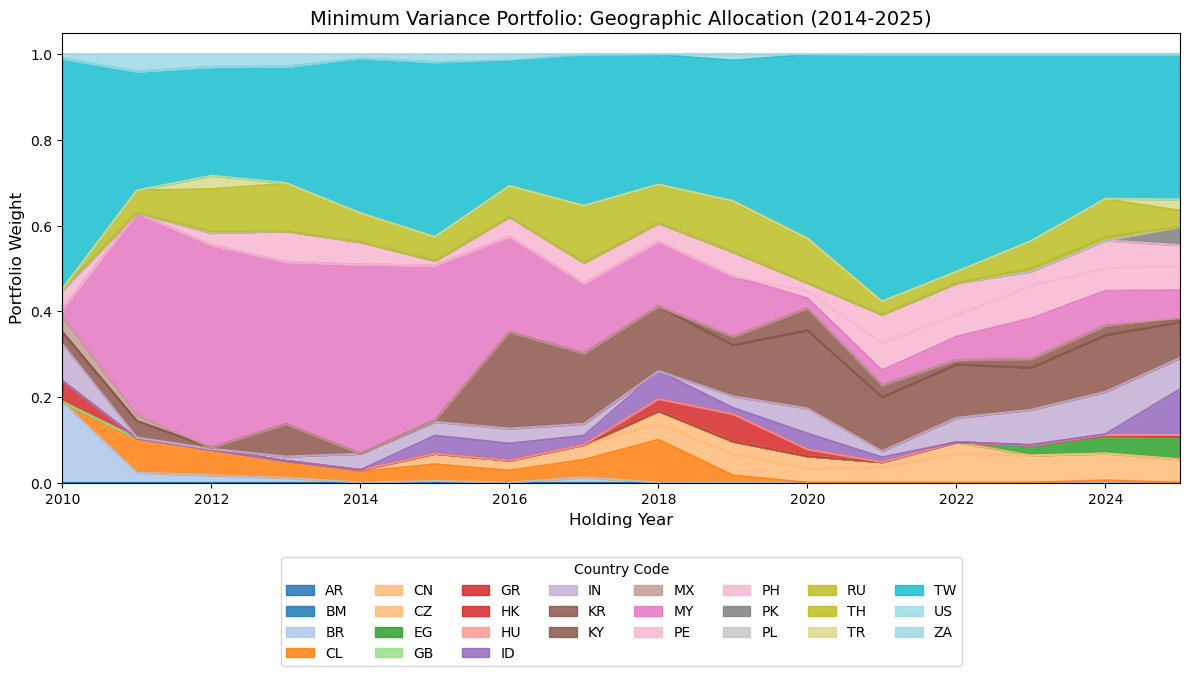

In [8]:
optimal_weights_mv    = {}
out_of_sample_returns = []
out_of_sample_dates   = []

for holding_year in sorted(sigma_estimates.keys()):

    Sigma_Y     = sigma_estimates[holding_year].to_numpy()
    valid_isins = sigma_estimates[holding_year].columns
    n_assets    = len(valid_isins)

    def portfolio_variance(alpha, cov_matrix):
        return (alpha.T @ cov_matrix @ alpha) * 10000

    constraints   = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1.0})
    bounds        = tuple((0.0, 1.0) for _ in range(n_assets))
    initial_alpha = np.ones(n_assets) / n_assets

    result = minimize(portfolio_variance, initial_alpha,
                      args=(Sigma_Y,), method='SLSQP',
                      bounds=bounds, constraints=constraints)

    if not result.success:
        print(f"Holding Year {holding_year}: Optimization FAILED.")
        continue

    alpha_Y = np.round(result.x, 6)
    alpha_Y = alpha_Y / np.sum(alpha_Y)
    optimal_weights_mv[holding_year] = pd.Series(alpha_Y, index=valid_isins)

    start_date_holding = f"{holding_year}-01-01"
    end_date_holding   = f"{holding_year}-12-31"
    holding_returns    = returns_em.loc[start_date_holding:end_date_holding,
                                        valid_isins].copy().fillna(0.0)

    current_alpha = alpha_Y.copy()

    for date, row in holding_returns.iterrows():
        R_tk = row.values
        R_p  = np.dot(current_alpha, R_tk)

        out_of_sample_returns.append(R_p)
        out_of_sample_dates.append(date)

        current_alpha = current_alpha * (1 + R_tk) / (1 + R_p)
        current_alpha = current_alpha / np.sum(current_alpha)

    print(f"Holding Year {holding_year}: Optimization and drift simulated.")

portfolio_oos_series = pd.Series(out_of_sample_returns, index=out_of_sample_dates)

# Slice to the evaluation period
portfolio_oos_series = portfolio_oos_series.loc['2014-01-01':'2025-12-31']
print(f"Final evaluated months: {len(portfolio_oos_series)} (Expected: 144)")

# Risk-free rate
rf_df    = pd.read_excel('Data_2026/Risk_Free_Rate_2025.xlsx',
                          sheet_name='F-F_Research_Data_Factors')
date_col = rf_df.columns[0]
rate_col = rf_df.columns[1]

rf_df[date_col] = pd.to_datetime(rf_df[date_col].astype(str), format='%Y%m')
rf_df.set_index(date_col, inplace=True)
rf_series = rf_df[rate_col] / 100.0

portfolio_oos_series.index = portfolio_oos_series.index.to_period('M')
rf_series.index            = rf_series.index.to_period('M')
rf_oos                     = rf_series.loc[portfolio_oos_series.index]

excess_returns    = portfolio_oos_series - rf_oos
ann_avg_return    = portfolio_oos_series.mean() * 12
ann_rf_rate       = rf_oos.mean() * 12
ann_volatility    = portfolio_oos_series.std() * np.sqrt(12)
ann_excess_return = excess_returns.mean() * 12
sharpe_ratio      = ann_excess_return / ann_volatility
min_return        = portfolio_oos_series.min()
max_return        = portfolio_oos_series.max()

portfolio_stats = pd.DataFrame({
    'Metric': [
        'Annualized Average Return (μ_p)',
        'Annualized Volatility (σ_p)',
        'Annualized Risk-Free Rate',
        'Sharpe Ratio (SR_p)',
        'Minimum Return',
        'Maximum Return'
    ],
    'Value': [ann_avg_return, ann_volatility, ann_rf_rate,
              sharpe_ratio, min_return, max_return]
})

display(portfolio_stats)

portfolio_oos_series.index = portfolio_oos_series.index.to_timestamp(how='end')
portfolio_oos_series.to_excel('Data_2026/Ex_Post_Returns_Simple_MV.xlsx',
                               header=['MV_Return'])
print("Final out-of-sample returns saved to 'Ex_Post_Returns_Simple_MV.xlsx'")

# Geographic allocation
weight_records = []
for year, weights_series in optimal_weights_mv.items():
    for isin, weight in weights_series.items():
        weight_records.append({'Holding_Year': year, 'ISIN': isin, 'Weight': weight})

df_all_weights             = pd.DataFrame(weight_records)
df_all_weights['Country']  = df_all_weights['ISIN'].str[:2]
country_alloc              = df_all_weights.groupby(
                                ['Holding_Year', 'Country'])['Weight'].sum().unstack().fillna(0)

ax = country_alloc.plot(kind='area', stacked=True, figsize=(12, 7),
                        colormap='tab20', alpha=0.85)

plt.title('Minimum Variance Portfolio: Geographic Allocation (2014-2025)', fontsize=14)
plt.ylabel('Portfolio Weight', fontsize=12)
plt.xlabel('Holding Year', fontsize=12)
plt.margins(x=0, y=0)
plt.legend(title='Country Code', loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=8)
plt.tight_layout()
plt.show()

The table reports annualized return, volatility, risk-free rate and Sharpe ratio for the minimum variance portfolio over the full evaluation period. The stacked area chart shows how the geographic allocation across EM countries evolves year by year from 2014 to 2025.

## 7. Value-Weighted Benchmark Portfolio — Report Sections 3.1–3.2

The value-weighted (VW) benchmark assigns each firm a weight proportional to its market capitalisation at the end of the previous month, avoiding any look-ahead bias:

$$w_{i,t} = \frac{Cap_{i,t}}{\sum_j Cap_{j,t}} \qquad R^{vw}_{t+1} = \sum_i w_{i,t} \cdot R_{i,t+1}$$

The benchmark is constructed over the same 2014–2025 evaluation period and the same annual investment universe as the minimum variance portfolio. Summary statistics for both portfolios are computed using the Fama-French monthly risk-free rate.

Holding Year 2014: value-weighted benchmark returns computed.
Holding Year 2015: value-weighted benchmark returns computed.
Holding Year 2016: value-weighted benchmark returns computed.
Holding Year 2017: value-weighted benchmark returns computed.
Holding Year 2018: value-weighted benchmark returns computed.
Holding Year 2019: value-weighted benchmark returns computed.
Holding Year 2020: value-weighted benchmark returns computed.
Holding Year 2021: value-weighted benchmark returns computed.
Holding Year 2022: value-weighted benchmark returns computed.
Holding Year 2023: value-weighted benchmark returns computed.
Holding Year 2024: value-weighted benchmark returns computed.
Holding Year 2025: value-weighted benchmark returns computed.
Final evaluated months for VW portfolio: 144 (Expected: 144)
Summary statistics comparison:


,Metric,Minimum Variance Portfolio,Value-Weighted Portfolio
0,Annualized average return,0.067202,0.082173
1,Annualized volatility,0.104769,0.155652
2,Annualized cumulative return,0.063581,0.072393
3,Sharpe ratio,0.474640,0.415660
4,Minimum monthly return,-0.075919,-0.167142
5,Maximum monthly return,0.121323,0.134062


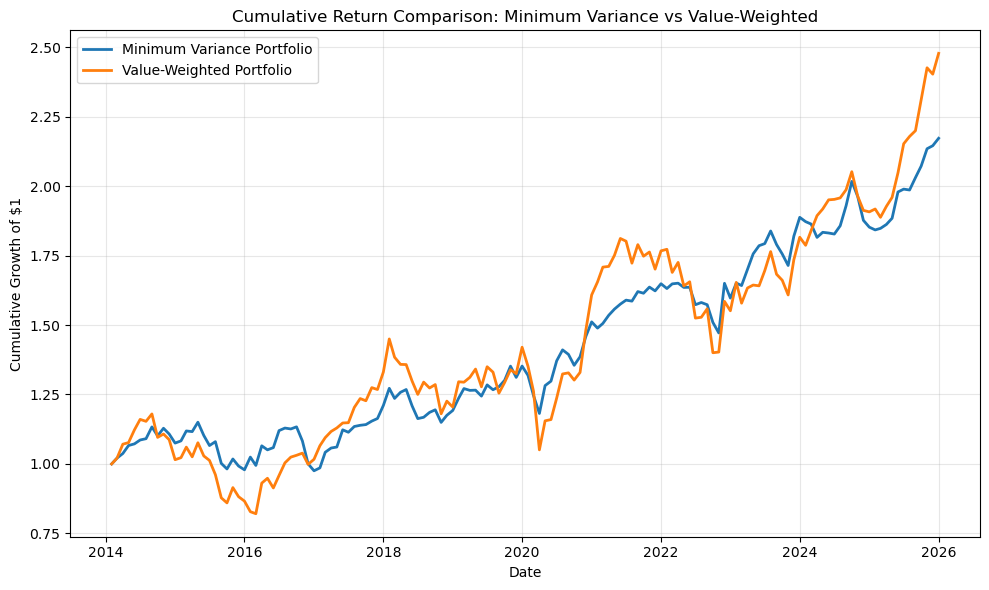

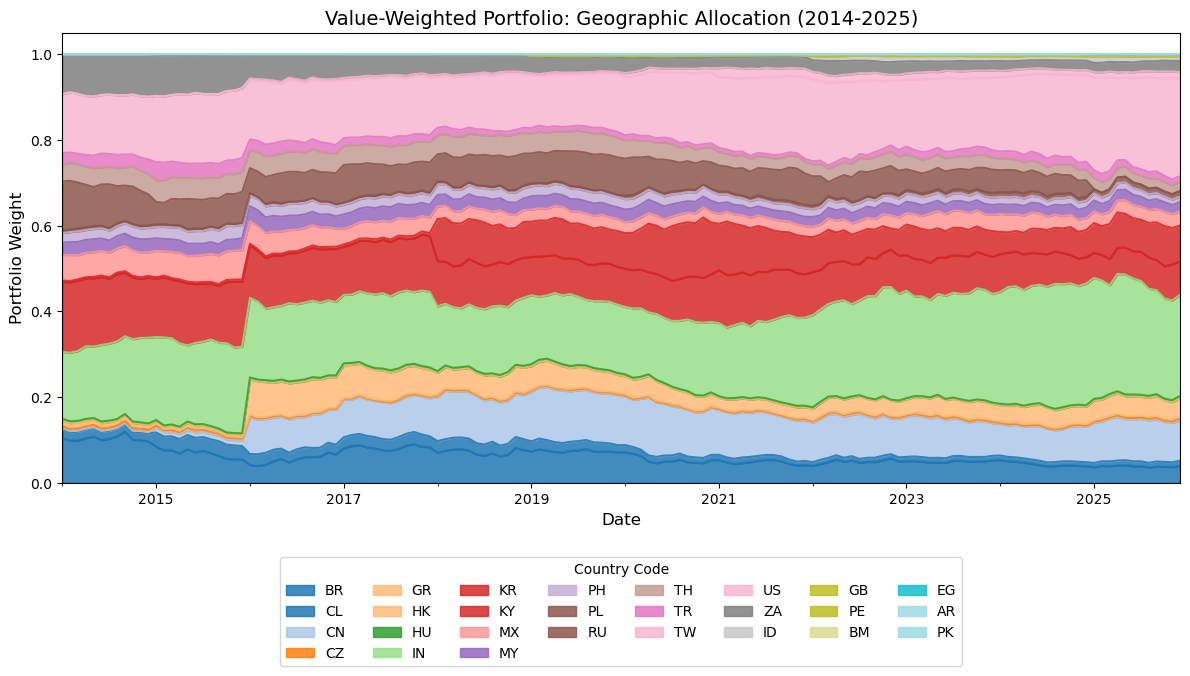

In [9]:
mktcap_monthly = load_and_transpose('Data_2026/DS_MV_T_USD_M_2025.xlsx', is_monthly=True)
mktcap_em      = mktcap_monthly[[isin for isin in valid_em_isins
                                  if isin in mktcap_monthly.columns]].copy()
mktcap_em        = mktcap_em.reindex(returns_em.index)
mktcap_em_lagged = mktcap_em.shift(1)

vw_out_of_sample_returns = []
vw_out_of_sample_dates   = []

for holding_year in sorted(valid_investment_sets.keys()):
    if holding_year < 2014 or holding_year > 2025:
        continue

    valid_isins = valid_investment_sets[holding_year]
    if len(valid_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31", valid_isins
    ].copy().fillna(0.0)

    holding_caps = mktcap_em_lagged.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31", valid_isins
    ].copy().fillna(0.0)

    for date, row_returns in holding_returns.iterrows():
        row_caps = holding_caps.loc[date].copy()
        if row_caps.sum() <= 0:
            R_vw = np.nan
        else:
            weights_vw = row_caps / row_caps.sum()
            R_vw       = np.dot(weights_vw.values, row_returns.values)

        vw_out_of_sample_returns.append(R_vw)
        vw_out_of_sample_dates.append(date)

    print(f"Holding Year {holding_year}: value-weighted benchmark returns computed.")

portfolio_vw_series = pd.Series(vw_out_of_sample_returns,
                                 index=vw_out_of_sample_dates)
portfolio_vw_series = portfolio_vw_series.loc['2014-01-01':'2025-12-31']
print(f"Final evaluated months for VW portfolio: {len(portfolio_vw_series)} (Expected: 144)")

portfolio_mv_series       = portfolio_oos_series.copy()
portfolio_mv_series       = portfolio_mv_series.loc['2014-01-01':'2025-12-31']
portfolio_mv_series.index = portfolio_mv_series.index.to_period('M')
portfolio_vw_series.index = portfolio_vw_series.index.to_period('M')

rf_df    = pd.read_excel('Data_2026/Risk_Free_Rate_2025.xlsx',
                          sheet_name='F-F_Research_Data_Factors')
date_col = rf_df.columns[0]
rate_col = rf_df.columns[1]
rf_df[date_col] = pd.to_datetime(rf_df[date_col].astype(str), format='%Y%m')
rf_df.set_index(date_col, inplace=True)
rf_series       = rf_df[rate_col] / 100.0
rf_series.index = rf_series.index.to_period('M')

rf_mv = rf_series.loc[portfolio_mv_series.index]
rf_vw = rf_series.loc[portfolio_vw_series.index]

mv_excess_returns = portfolio_mv_series - rf_mv
vw_excess_returns = portfolio_vw_series - rf_vw

mv_ann_avg_return    = portfolio_mv_series.mean() * 12
mv_ann_volatility    = portfolio_mv_series.std() * np.sqrt(12)
mv_ann_cum_return    = (1 + portfolio_mv_series).prod() ** (12 / len(portfolio_mv_series)) - 1
mv_ann_excess_return = mv_excess_returns.mean() * 12
mv_sharp_ratio       = mv_ann_excess_return / mv_ann_volatility if mv_ann_volatility != 0 else np.nan
mv_min_return        = portfolio_mv_series.min()
mv_max_return        = portfolio_mv_series.max()

vw_ann_avg_return    = portfolio_vw_series.mean() * 12
vw_ann_volatility    = portfolio_vw_series.std() * np.sqrt(12)
vw_ann_cum_return    = (1 + portfolio_vw_series).prod() ** (12 / len(portfolio_vw_series)) - 1
vw_ann_excess_return = vw_excess_returns.mean() * 12
vw_sharp_ratio       = vw_ann_excess_return / vw_ann_volatility if vw_ann_volatility != 0 else np.nan
vw_min_return        = portfolio_vw_series.min()
vw_max_return        = portfolio_vw_series.max()

comparison_stats = pd.DataFrame({
    'Metric': [
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return'
    ],
    'Minimum Variance Portfolio': [mv_ann_avg_return, mv_ann_volatility,
                                    mv_ann_cum_return, mv_sharp_ratio,
                                    mv_min_return, mv_max_return],
    'Value-Weighted Portfolio':   [vw_ann_avg_return, vw_ann_volatility,
                                    vw_ann_cum_return, vw_sharp_ratio,
                                    vw_min_return, vw_max_return]
})

print("Summary statistics comparison:")
display(comparison_stats)

mv_plot       = portfolio_mv_series.copy()
vw_plot       = portfolio_vw_series.copy()
mv_plot.index = mv_plot.index.to_timestamp(how='end')
vw_plot.index = vw_plot.index.to_timestamp(how='end')

mv_cumulative = (1 + mv_plot).cumprod()
vw_cumulative = (1 + vw_plot).cumprod()
mv_cumulative = mv_cumulative / mv_cumulative.iloc[0]
vw_cumulative = vw_cumulative / vw_cumulative.iloc[0]

plt.figure(figsize=(10, 6))
plt.plot(mv_cumulative.index, mv_cumulative.values, linewidth=2,
         label='Minimum Variance Portfolio')
plt.plot(vw_cumulative.index, vw_cumulative.values, linewidth=2,
         label='Value-Weighted Portfolio')
plt.title('Cumulative Return Comparison: Minimum Variance vs Value-Weighted')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

output_dir = "Data_2026/plots_mv_vs_vw"
os.makedirs(output_dir, exist_ok=True)

comparison_stats.to_excel('Data_2026/Comparison_MV_vs_VW.xlsx', index=False)

comparison_returns = pd.DataFrame({
    'Minimum_Variance_Return':      mv_plot,
    'Value_Weighted_Return':        vw_plot,
    'Minimum_Variance_Cumulative':  mv_cumulative,
    'Value_Weighted_Cumulative':    vw_cumulative
})
comparison_returns.to_excel('Data_2026/Cumulative_Returns_MV_vs_VW.xlsx')

plt.figure(figsize=(10, 6))
plt.plot(mv_cumulative.index, mv_cumulative.values, linewidth=2,
         label='Minimum Variance Portfolio')
plt.plot(vw_cumulative.index, vw_cumulative.values, linewidth=2,
         label='Value-Weighted Portfolio')
plt.title('Cumulative Return Comparison: Minimum Variance vs Value-Weighted')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/Cumulative_Return_Comparison_MV_vs_VW.png",
            dpi=300, bbox_inches='tight')
plt.close()

# Geographic allocation for the VW portfolio
vw_country_weights_list = []

for date in vw_out_of_sample_dates:
    holding_year = pd.to_datetime(date).year
    if holding_year not in valid_investment_sets:
        continue
    valid_isins = valid_investment_sets[holding_year]
    row_caps    = mktcap_em_lagged.loc[date, valid_isins].fillna(0.0)
    total_cap   = row_caps.sum()

    if total_cap > 0:
        weights_vw      = row_caps / total_cap
        country_weights = weights_vw.groupby(weights_vw.index.str[:2]).sum()
        country_weights['Date'] = pd.to_datetime(date)
        vw_country_weights_list.append(country_weights)

df_vw_alloc = pd.DataFrame(vw_country_weights_list)
df_vw_alloc.set_index('Date', inplace=True)
df_vw_alloc = df_vw_alloc.fillna(0.0)

ax = df_vw_alloc.plot(kind='area', stacked=True, figsize=(12, 7),
                       colormap='tab20', alpha=0.85)
plt.title('Value-Weighted Portfolio: Geographic Allocation (2014-2025)', fontsize=14)
plt.ylabel('Portfolio Weight', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.margins(x=0, y=0)
plt.legend(title='Country Code', loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=8)
plt.tight_layout()
plt.savefig(f"{output_dir}/Geographic_Allocation_VW.png", dpi=300, bbox_inches='tight')
plt.show()

The table compares annualized return, volatility, cumulative return and Sharpe ratio for the minimum variance and value-weighted portfolios. The cumulative return chart shows the growth of $1 invested in each portfolio from January 2014 to December 2025. The stacked area chart shows the evolution of geographic allocation within the value-weighted benchmark over the same period.

## 8. Carbon Emissions Metrics — Report Section 4.1

Two carbon metrics are computed annually for both the minimum variance and value-weighted portfolios over the 2014–2025 evaluation period, using emissions and revenue data from the prior year $Y-1$.

The **Weighted-Average Carbon Intensity (WACI)** measures carbon efficiency relative to revenue:

$$WACI = \sum_i w_i \cdot \frac{E_i}{Rev_i}$$

The **Carbon Footprint (CF)** measures the portfolio's proportional ownership of absolute emissions:

$$CF = \frac{1}{V} \sum_i \frac{w_i \cdot V}{Cap_i} \cdot E_i$$

where $E_i$ is total Scope 1 + Scope 2 emissions, $Rev_i$ is revenue in millions USD, $Cap_i$ is market capitalisation and $V$ is portfolio wealth. Portfolio wealth is tracked dynamically from a base of \$1M in 2013 using compounded annual returns.

Top 10 WACI Drivers — Value-Weighted Portfolio (Average 2014-2025)


,Name,Contrib
ISIN,,
INE733E01010,NTPC,69.1396
INE481G01011,ULTRATECH CEMENT,31.5190
RU0007661625,GAZPROM,23.5022
ZAE000006896,SASOL,18.4078
MYL1961OO001,IOI CORPORATION,11.8115
TW0002330008,TAIWAN SEMICON.MNFG.,10.6635
RU000A0J2Q06,OC ROSNEFT,9.6992
MYL5347OO009,TENAGA NASIONAL,9.5713
INE002A01018,RELIANCE INDUSTRIES,9.4533



Top 10 WACI Drivers — Minimum Variance Portfolio (Average 2014-2025)


,Name,Contrib
ISIN,,
ID1000106800,SEMEN INDONESIA (PERSERO),88.5984
PEP702101002,ENGIE ENERGIA PERU,58.2516
PEP700511004,ORYGEN PERU,55.1599
TH0637010Y00,RATCH GROUP PCL,50.5225
TH0465010005,ELECTRICITY GENERATING,45.7681
CNE1000002S8,COSCO SHIP.EN.TRSP. 'H',21.8886
TW0002412004,CHUNGHWA TELECOM,19.3476
MYL6033OO004,PETRONAS GAS,17.8638
CLP3615W1037,COLBUN MACHICURA,16.7520



Annual Carbon Metrics Comparison


,WACI_VW,WACI_MV,CF_VW,CF_MV
Year,,,,
2014,572.01,294.28,463.61,156.90
2015,631.71,676.09,582.29,236.64
2016,516.44,486.51,463.96,188.06
2017,627.97,421.26,707.53,271.87
2018,702.10,371.64,664.46,136.37
2019,484.91,885.79,590.58,375.00
2020,587.85,628.22,690.26,275.01
2021,416.44,438.86,673.99,321.84
2022,423.10,669.59,589.68,400.57


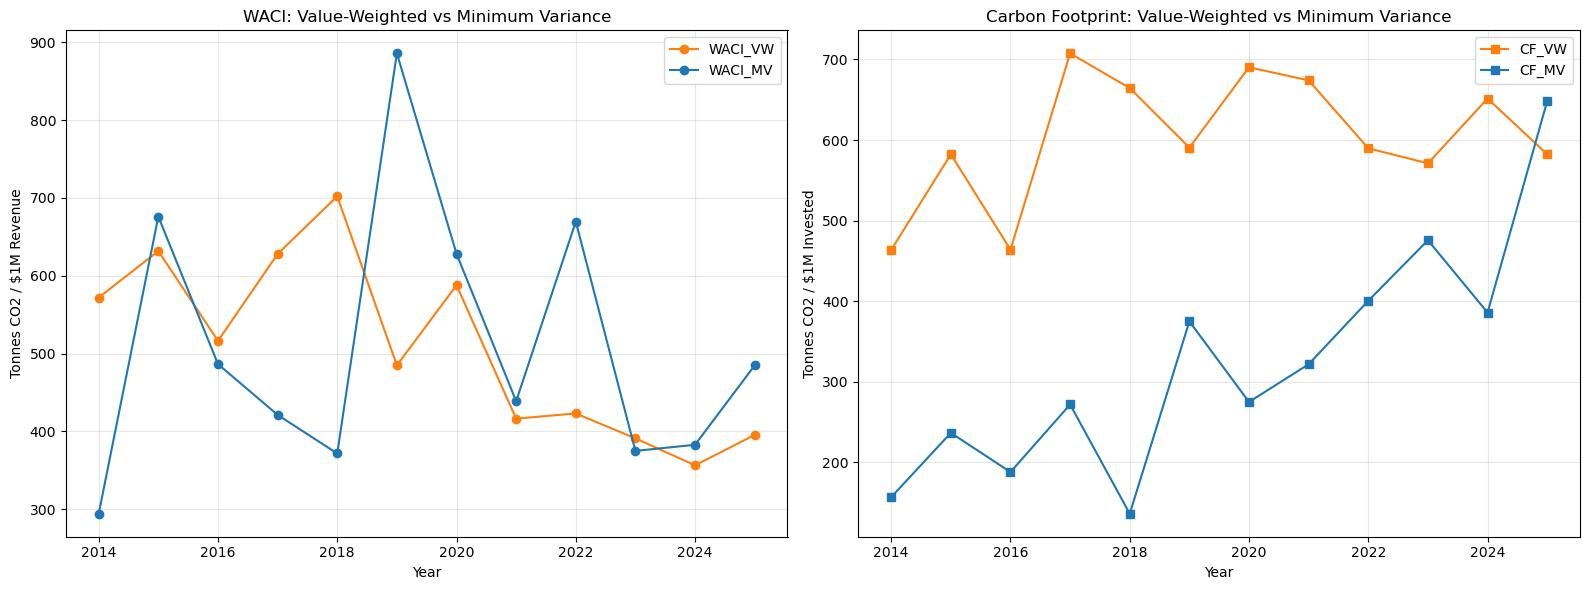

In [10]:
base_output_dir  = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
os.makedirs(plots_output_dir, exist_ok=True)

static_names = pd.read_excel("Data_2026/Static_2025.xlsx")
static_names['ISIN'] = static_names['ISIN'].astype(str).str.strip()
isin_to_name = dict(zip(static_names['ISIN'], static_names['NAME']))

rev_raw = load_and_transpose("Data_2026/DS_REV_Y_2025.xlsx",       is_monthly=False)
cap_raw = load_and_transpose("Data_2026/DS_MV_T_USD_Y_2025.xlsx",  is_monthly=False)

rev_y = rev_raw[valid_em_isins].replace(0.0, np.nan).sort_index().ffill()
cap_y = cap_raw[valid_em_isins].replace(0.0, np.nan).sort_index().ffill()

rev_musd_y = rev_y / 1000.0
E_total_y  = scope1_em + scope2_em
CI_y       = E_total_y / rev_musd_y

annual_ret_vw = portfolio_vw_series.groupby(
    portfolio_vw_series.index.year).apply(lambda x: (1 + x).prod() - 1)
annual_ret_mv = portfolio_oos_series.groupby(
    portfolio_oos_series.index.year).apply(lambda x: (1 + x).prod() - 1)

# Starting wealth is 1.0 representing 1,000,000 USD expressed in millions.
# All CF values are therefore in tCO2e per 1 million USD invested as required by the guidelines.
wealth_vw = {2013: 1.0}
wealth_mv = {2013: 1.0}

for year in range(2014, 2026):
    wealth_vw[year] = wealth_vw[year-1] * (1 + annual_ret_vw.get(year, 0))
    wealth_mv[year] = wealth_mv[year-1] * (1 + annual_ret_mv.get(year, 0))

carbon_results   = []
vw_contributions = []
mv_contributions = []

for holding_year in range(2014, 2026):
    data_year = holding_year - 1

    if holding_year not in optimal_weights_mv:
        continue

    weights_mv_all = optimal_weights_mv[holding_year]
    isins          = weights_mv_all.index.tolist()

    E_t   = E_total_y.loc[data_year, isins]
    CI_t  = CI_y.loc[data_year, isins]
    Cap_t = cap_y.loc[data_year, isins]

    valid_mask  = CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins = CI_t[valid_mask].index.tolist()

    if len(valid_isins) == 0:
        continue

    w_mv = weights_mv_all[valid_isins]
    w_mv = w_mv / w_mv.sum()
    w_vw = Cap_t[valid_isins] / Cap_t[valid_isins].sum()

    WACI_vw = np.sum(w_vw * CI_t[valid_isins])
    WACI_mv = np.sum(w_mv * CI_t[valid_isins])

    V_vw   = wealth_vw[data_year]
    V_mv   = wealth_mv[data_year]

    o_i_vw = (w_vw * V_vw) / Cap_t[valid_isins]
    o_i_mv = (w_mv * V_mv) / Cap_t[valid_isins]

    CF_vw = (1 / V_vw) * np.sum(o_i_vw * E_t[valid_isins])
    CF_mv = (1 / V_mv) * np.sum(o_i_mv * E_t[valid_isins])

    carbon_results.append({
        'Year':    holding_year,
        'WACI_VW': WACI_vw, 'WACI_MV': WACI_mv,
        'CF_VW':   CF_vw,   'CF_MV':   CF_mv
    })

    vw_contributions.append(pd.DataFrame({
        'ISIN':   valid_isins,
        'Contrib': (w_vw * CI_t[valid_isins]).values
    }))
    mv_contributions.append(pd.DataFrame({
        'ISIN':   valid_isins,
        'Contrib': (w_mv * CI_t[valid_isins]).values
    }))

df_metrics = pd.DataFrame(carbon_results).set_index('Year')

num_years = 12

top10_vw = pd.concat(vw_contributions).reset_index(drop=True).groupby('ISIN').sum() / num_years
top10_vw = top10_vw.sort_values('Contrib', ascending=False).head(10)
top10_vw['Name'] = [isin_to_name.get(i, i) for i in top10_vw.index]

top10_mv = pd.concat(mv_contributions).reset_index(drop=True).groupby('ISIN').sum() / num_years
top10_mv = top10_mv.sort_values('Contrib', ascending=False).head(10)
top10_mv['Name'] = [isin_to_name.get(i, i) for i in top10_mv.index]

print("Top 10 WACI Drivers — Value-Weighted Portfolio (Average 2014-2025)")
display(top10_vw[['Name', 'Contrib']].round(4))

print("\nTop 10 WACI Drivers — Minimum Variance Portfolio (Average 2014-2025)")
display(top10_mv[['Name', 'Contrib']].round(4))

print("\nAnnual Carbon Metrics Comparison")
display(df_metrics.round(2))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

df_metrics[['WACI_VW', 'WACI_MV']].plot(
    ax=ax[0], marker='o', color=['tab:orange', 'tab:blue'],
    title="WACI: Value-Weighted vs Minimum Variance")
ax[0].set_ylabel("Tonnes CO2 / $1M Revenue")
ax[0].grid(True, alpha=0.3)

df_metrics[['CF_VW', 'CF_MV']].plot(
    ax=ax[1], marker='s', color=['tab:orange', 'tab:blue'],
    title="Carbon Footprint: Value-Weighted vs Minimum Variance")
ax[1].set_ylabel("Tonnes CO2 / $1M Invested")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Carbon_Metrics_Comparison.png"), dpi=300)
plt.show()

The two tables report the top 10 firms contributing most to WACI on average over 2014–2025 for each portfolio. The annual metrics table shows WACI and carbon footprint year by year. The two charts compare the evolution of both metrics across the minimum variance and value-weighted portfolios.

## 9. Carbon-Constrained MV Portfolio (50% CF) — Report Section 4.2

The baseline minimum variance portfolio is augmented with a carbon footprint constraint that requires the portfolio's carbon footprint to be at most 50% of the unconstrained baseline level in each holding year. The optimization problem becomes:

$$\min_w \; w' \Sigma_Y w \qquad \text{s.t.} \quad w' \mathbf{e} = 1, \quad w_i \geq 0, \quad \sum_i w_i \cdot \frac{E_i}{Cap_i} \leq 0.5 \cdot CF^{baseline}_Y$$

where $E_i / Cap_i$ is the firm-level carbon intensity per unit of market capitalisation. If the optimizer fails to find a feasible solution, a fallback assigns equal weights to the half of the universe with the lowest carbon intensity. The objective function is scaled by a factor of 10,000 for numerical stability of the SLSQP solver; this does not affect the optimal solution.

Summary Statistics Comparison


,Metric,Minimum Variance Portfolio,Value-Weighted Portfolio,Minimum Variance (50% CF)
0,Annualized average return,0.0672,0.0822,0.0652
1,Annualized volatility,0.1048,0.1557,0.1003
2,Annualized cumulative return,0.0636,0.0724,0.0619
3,Sharpe ratio,0.4746,0.4157,0.4756
4,Minimum monthly return,-0.0759,-0.1671,-0.0676
5,Maximum monthly return,0.1213,0.1341,0.1193



Carbon Metrics: Baseline MV vs MV (50% CF Reduction)


,WACI_MV,WACI_MV_05,CF_MV,CF_MV_05
Year,,,,
2014,294.28,187.79,156.90,78.45
2015,676.09,279.22,236.64,118.32
2016,486.51,263.27,188.06,94.03
2017,421.26,184.41,271.87,135.93
2018,371.64,158.56,136.37,68.19
2019,885.79,413.99,375.00,187.50
2020,628.22,274.11,275.01,137.51
2021,438.86,325.56,321.84,160.92
2022,669.59,527.67,400.57,200.29


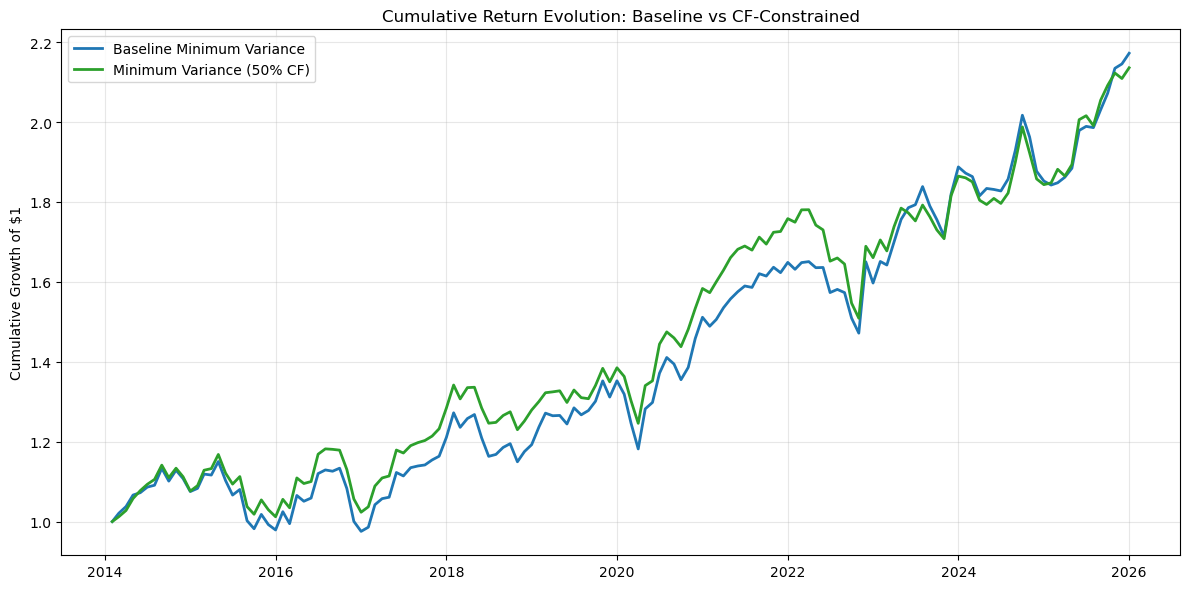

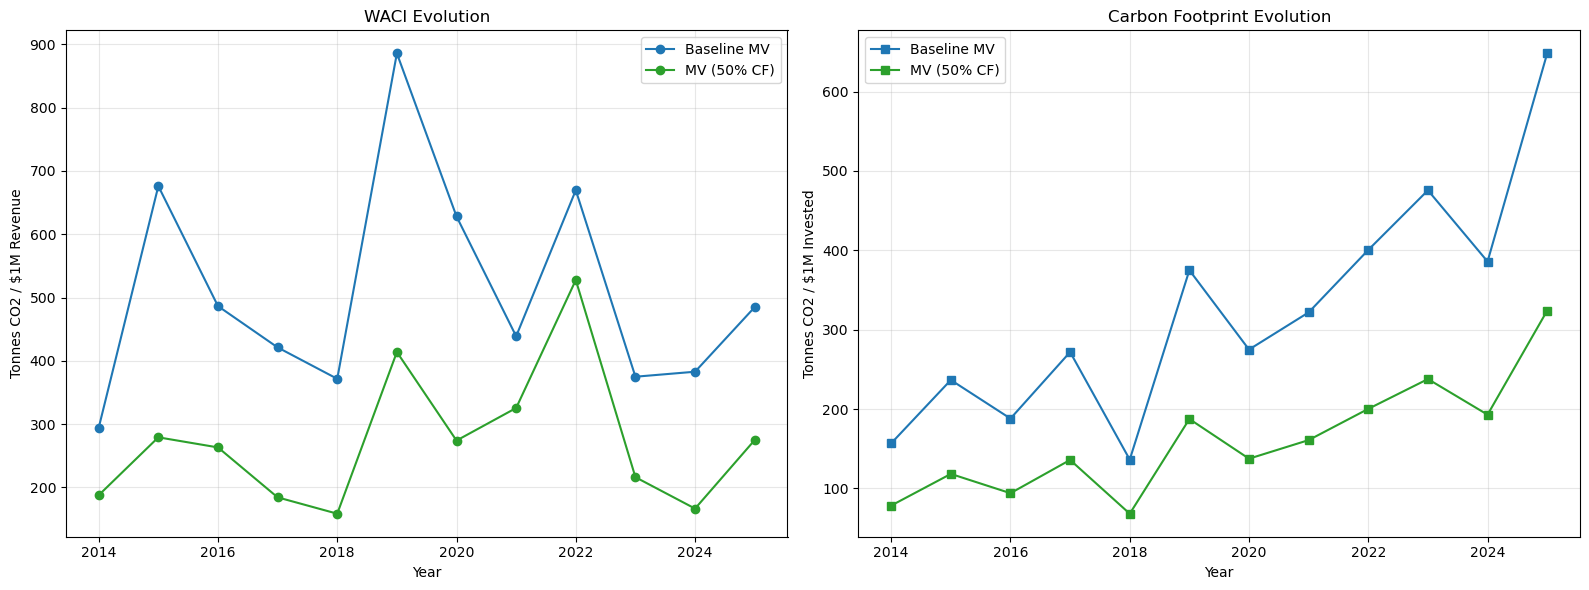


Excluded Firms: Top 5 completely dropped from the portfolio


,ISIN,Name,Years_Excluded
50,TW0003045001,TAIWAN MOBILE,5
51,TW0004904008,FAR EASTONE TELECOM.,4
26,MYL4707OO005,NESTLE (MALAYSIA),4
16,INE752E01010,POWER GRID CORPORATION OF INDIA,3
52,TW0009917005,TAIWAN SECOM,3



Historical Average: Top 5 Under-Weighted Firms


,Name,Baseline_MV,MV_05,Shift
MYL4162OO003,BRIT.AMER.TOB.(MALAYSIA),0.1457,0.0569,-0.0888
TW0003045001,TAIWAN MOBILE,0.0929,0.0279,-0.0650
TH0268010Z03,ADVANCED INFO SER.,0.0360,0.0126,-0.0234
BRCPFEACNOR0,CPFL ENERGIA ON,0.0171,0.0000,-0.0171
MYL4863OO006,TELEKOM MALAYSIA,0.0424,0.0262,-0.0163



Historical Average: Top 5 Over-Weighted Firms


,Name,Baseline_MV,MV_05,Shift
TW0002412004,CHUNGHWA TELECOM,0.2545,0.3158,0.0614
MYL4065OO008,PPB GROUP,0.0036,0.0085,0.0049
TH0450010Y08,THAI UNION GROUP,0.0265,0.0314,0.0048
TW0002357001,ASUSTEK COMPUTER,0.0009,0.0055,0.0046
MYL5235SS008,KLCC PROPERTY HOLDINGS STAPLED UNITS,0.0123,0.0167,0.0044


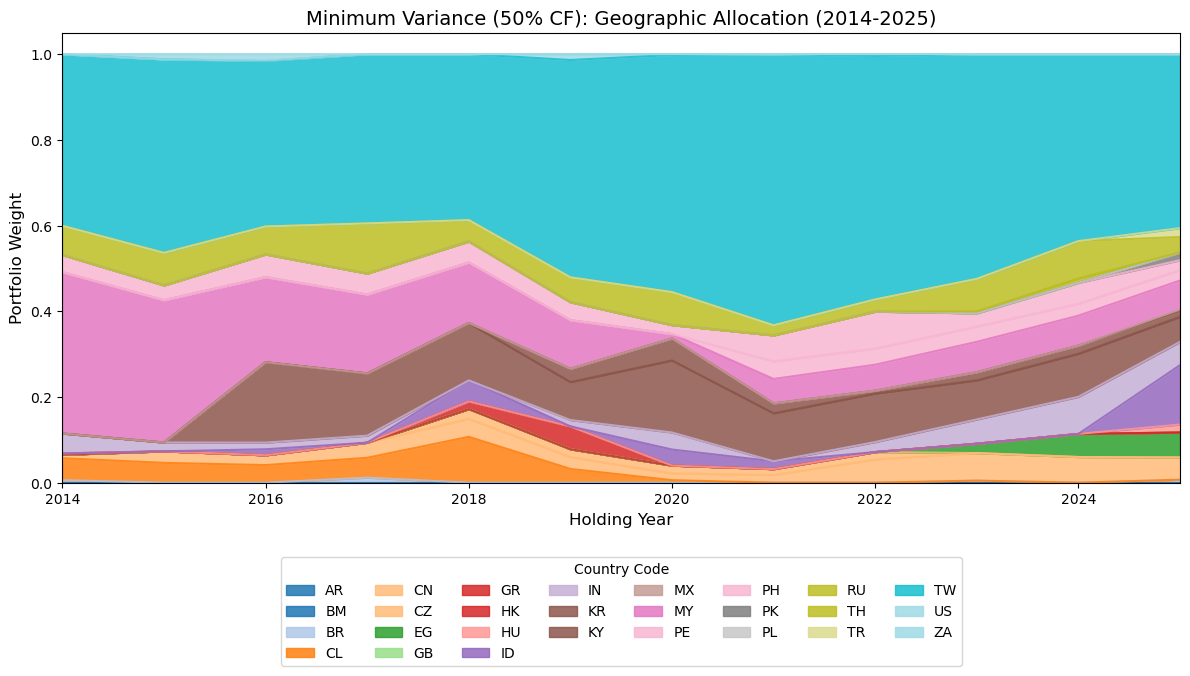

In [11]:
base_output_dir     = "outputs"
plots_output_dir    = os.path.join(base_output_dir, "plots_carbon_metrics")
analysis_output_dir = os.path.join(base_output_dir, "composition_analysis")
os.makedirs(plots_output_dir,    exist_ok=True)
os.makedirs(analysis_output_dir, exist_ok=True)

static_names = pd.read_excel("Data_2026/Static_2025.xlsx")
static_names['ISIN'] = static_names['ISIN'].astype(str).str.strip()
isin_to_name = dict(zip(static_names['ISIN'], static_names['NAME']))

optimal_weights_mv_05 = {}
returns_mv_05         = []
dates_mv_05           = []
yearly_shifts         = []

for holding_year in range(2014, 2026):
    data_year = holding_year - 1

    if holding_year not in sigma_estimates or holding_year not in optimal_weights_mv:
        continue

    w_mv_baseline_all = optimal_weights_mv[holding_year]
    Sigma_Y_all       = sigma_estimates[holding_year]
    isins             = w_mv_baseline_all.index.tolist()

    E_t   = E_total_y.loc[data_year, isins]
    CI_t  = CI_y.loc[data_year, isins]
    Cap_t = cap_y.loc[data_year, isins]

    valid_mask  = CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins = CI_t[valid_mask].index.tolist()
    n_assets    = len(valid_isins)

    if n_assets == 0:
        continue

    Sigma_sub    = Sigma_Y_all.loc[valid_isins, valid_isins].to_numpy()
    w_mv_base    = w_mv_baseline_all[valid_isins].to_numpy()
    w_mv_base    = w_mv_base / np.sum(w_mv_base)
    c_vector     = (E_t[valid_isins] / Cap_t[valid_isins]).to_numpy()
    CF_baseline_Y = np.dot(w_mv_base, c_vector)
    CF_target_Y   = 0.5 * CF_baseline_Y

    def portfolio_variance(w, cov_matrix):
        return (w.T @ cov_matrix @ w) * 10000

    constraints = [
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq', 'fun': lambda w: (CF_target_Y - np.dot(w, c_vector)) /
                                           max(CF_baseline_Y, 1e-6)}  # Dividing by CF_baseline_Y normalises the constraint scale for the solver; the feasible region is unchanged.
    ]
    bounds    = tuple((0.0, 1.0) for _ in range(n_assets))
    initial_w = np.ones(n_assets) / n_assets

    res = minimize(portfolio_variance, initial_w, args=(Sigma_sub,),
                   method='SLSQP', bounds=bounds, constraints=constraints)

    if not res.success:
        sorted_indices = np.argsort(c_vector)
        fallback_w     = np.zeros(n_assets)
        half_n         = max(1, n_assets // 2)
        fallback_w[sorted_indices[:half_n]] = 1.0 / half_n
        w_opt = fallback_w
    else:
        w_opt = np.round(res.x, 6)
        w_opt = w_opt / np.sum(w_opt)

    optimal_weights_mv_05[holding_year] = pd.Series(w_opt, index=valid_isins)

    year_shift_df = pd.DataFrame({
        'Year':          holding_year,
        'ISIN':          valid_isins,
        'Name':          [isin_to_name.get(i, i) for i in valid_isins],
        'Weight_MV':     w_mv_base,
        'Weight_MV_CF50': w_opt,
        'Delta_Weight':  w_opt - w_mv_base
    })
    yearly_shifts.append(year_shift_df)

    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31", valid_isins
    ].fillna(0.0)

    current_w = w_opt.copy()

    for date, row in holding_returns.iterrows():
        R_tk = row.values
        R_p  = np.dot(current_w, R_tk)
        returns_mv_05.append(R_p)
        dates_mv_05.append(date)
        current_w = current_w * (1 + R_tk) / (1 + R_p)
        current_w = current_w / np.sum(current_w)

portfolio_mv_05_series       = pd.Series(returns_mv_05,
                                          index=dates_mv_05).loc['2014-01-01':'2025-12-31']
portfolio_mv_05_series.index = portfolio_mv_05_series.index.to_period('M')

df_yearly_shifts = pd.concat(yearly_shifts, ignore_index=True)
df_yearly_shifts.to_excel(
    os.path.join(analysis_output_dir, "Year_by_Year_Composition_Shifts.xlsx"), index=False)

rf_mv_05             = rf_series.loc[portfolio_mv_05_series.index]
mv_05_excess_returns = portfolio_mv_05_series - rf_mv_05

ann_ret_05   = portfolio_mv_05_series.mean() * 12
ann_vol_05   = portfolio_mv_05_series.std() * np.sqrt(12)
ann_cum_05   = (1 + portfolio_mv_05_series).prod() ** (12 / len(portfolio_mv_05_series)) - 1
sharpe_05    = (mv_05_excess_returns.mean() * 12) / ann_vol_05 if ann_vol_05 != 0 else np.nan
min_ret_05   = portfolio_mv_05_series.min()
max_ret_05   = portfolio_mv_05_series.max()

comparison_stats['Minimum Variance (50% CF)'] = [
    ann_ret_05, ann_vol_05, ann_cum_05, sharpe_05, min_ret_05, max_ret_05
]

print("Summary Statistics Comparison")
display(comparison_stats.round(4))

annual_ret_mv_05 = portfolio_mv_05_series.groupby(
    portfolio_mv_05_series.index.year).apply(lambda x: (1 + x).prod() - 1)
wealth_mv_05 = {2013: 1.0}
for year in range(2014, 2026):
    wealth_mv_05[year] = wealth_mv_05[year-1] * (1 + annual_ret_mv_05.get(year, 0))

metrics_05 = []
for holding_year in range(2014, 2026):
    data_year = holding_year - 1
    w_05      = optimal_weights_mv_05[holding_year]
    isins     = w_05.index.tolist()
    E_t       = E_total_y.loc[data_year, isins]
    CI_t      = CI_y.loc[data_year, isins]
    Cap_t     = cap_y.loc[data_year, isins]

    WACI_05 = np.sum(w_05 * CI_t)
    V_05    = wealth_mv_05[data_year]
    o_i_05  = (w_05 * V_05) / Cap_t
    CF_05   = (1 / V_05) * np.sum(o_i_05 * E_t)

    metrics_05.append({'Year': holding_year, 'WACI_MV_05': WACI_05, 'CF_MV_05': CF_05})

df_metrics_05  = pd.DataFrame(metrics_05).set_index('Year')
df_all_metrics = df_metrics.join(df_metrics_05)

print("\nCarbon Metrics: Baseline MV vs MV (50% CF Reduction)")
display(df_all_metrics[['WACI_MV', 'WACI_MV_05', 'CF_MV', 'CF_MV_05']].round(2))

mv_05_plot       = portfolio_mv_05_series.copy()
mv_05_plot.index = mv_05_plot.index.to_timestamp(how='end')
mv_05_cumulative = (1 + mv_05_plot).cumprod()
mv_05_cumulative = mv_05_cumulative / mv_05_cumulative.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(mv_cumulative.index,    mv_cumulative.values,    linewidth=2,
         label='Baseline Minimum Variance', color='tab:blue')
plt.plot(mv_05_cumulative.index, mv_05_cumulative.values, linewidth=2,
         label='Minimum Variance (50% CF)', color='tab:green')
plt.title('Cumulative Return Evolution: Baseline vs CF-Constrained')
plt.ylabel('Cumulative Growth of $1')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_2_CumulativeReturn.png"), dpi=300)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

df_all_metrics[['WACI_MV', 'WACI_MV_05']].plot(
    ax=ax[0], marker='o', color=['tab:blue', 'tab:green'])
ax[0].set_title('WACI Evolution')
ax[0].set_ylabel('Tonnes CO2 / $1M Revenue')
ax[0].grid(True, alpha=0.3)
ax[0].legend(['Baseline MV', 'MV (50% CF)'])

df_all_metrics[['CF_MV', 'CF_MV_05']].plot(
    ax=ax[1], marker='s', color=['tab:blue', 'tab:green'])
ax[1].set_title('Carbon Footprint Evolution')
ax[1].set_ylabel('Tonnes CO2 / $1M Invested')
ax[1].grid(True, alpha=0.3)
ax[1].legend(['Baseline MV', 'MV (50% CF)'])

plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_2_CarbonEvolution.png"), dpi=300)
plt.show()

excluded_mask     = (df_yearly_shifts['Weight_MV'] > 0.001) & \
                    (df_yearly_shifts['Weight_MV_CF50'] < 0.00001)
excluded_firms_df = df_yearly_shifts[excluded_mask]
most_excluded     = excluded_firms_df.groupby(['ISIN', 'Name']).size().reset_index(
                        name='Years_Excluded')
most_excluded     = most_excluded.sort_values(by='Years_Excluded', ascending=False).head(5)

print("\nExcluded Firms: Top 5 completely dropped from the portfolio")
display(most_excluded)

num_years        = 12
avg_weights_base = pd.DataFrame(optimal_weights_mv).fillna(0).sum(axis=1)    / num_years
avg_weights_05   = pd.DataFrame(optimal_weights_mv_05).fillna(0).sum(axis=1) / num_years

weight_diff = pd.DataFrame({
    'Baseline_MV': avg_weights_base,
    'MV_05':       avg_weights_05,
    'Shift':       avg_weights_05 - avg_weights_base
}).fillna(0)
weight_diff['Name'] = [isin_to_name.get(i, i) for i in weight_diff.index]

top_underweighted = weight_diff.sort_values(by='Shift').head(5)
top_overweighted  = weight_diff.sort_values(by='Shift', ascending=False).head(5)

print("\nHistorical Average: Top 5 Under-Weighted Firms")
display(top_underweighted[['Name', 'Baseline_MV', 'MV_05', 'Shift']].round(4))

print("\nHistorical Average: Top 5 Over-Weighted Firms")
display(top_overweighted[['Name', 'Baseline_MV', 'MV_05', 'Shift']].round(4))

weight_records_05 = []
for year, weights_series in optimal_weights_mv_05.items():
    for isin, weight in weights_series.items():
        weight_records_05.append({'Holding_Year': year, 'ISIN': isin, 'Weight': weight})

df_weights_05              = pd.DataFrame(weight_records_05)
df_weights_05['Country']   = df_weights_05['ISIN'].str[:2]
country_alloc_05           = df_weights_05.groupby(
                                ['Holding_Year', 'Country'])['Weight'].sum().unstack().fillna(0)

ax = country_alloc_05.plot(kind='area', stacked=True, figsize=(12, 7),
                            colormap='tab20', alpha=0.85)
plt.title('Minimum Variance (50% CF): Geographic Allocation (2014-2025)', fontsize=14)
plt.ylabel('Portfolio Weight', fontsize=12)
plt.xlabel('Holding Year', fontsize=12)
plt.margins(x=0, y=0)
plt.legend(title='Country Code', loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_2_Geographic_Allocation.png"),
            dpi=300, bbox_inches='tight')
plt.show()

The summary statistics table compares the constrained portfolio against the baseline minimum variance and value-weighted benchmarks. The carbon metrics table confirms whether the 50% footprint reduction target is achieved each year. The composition analysis identifies which firms are excluded or systematically under- and over-weighted relative to the unconstrained portfolio. The geographic allocation chart shows how the country composition shifts under the carbon constraint.

## 10. Tracking Error Minimization (50% CF) — Report Section 4.3

The tracking error portfolio minimizes the deviation from the value-weighted benchmark while imposing the same 50% carbon footprint reduction constraint as in Section 9. The benchmark weights are defined as $w^{vw}_{i,Y} = Cap_{i,Y} / \sum_j Cap_{j,Y}$ and the optimization problem is:

$$\min_w \; (w - w^{vw})' \Sigma_Y (w - w^{vw}) \qquad \text{s.t.} \quad w'\mathbf{e} = 1, \quad w_i \geq 0, \quad \sum_i w_i \cdot \frac{E_i}{Cap_i} \leq 0.5 \cdot CF^{vw}_Y$$

The covariance matrix is regularized with a small diagonal term for numerical stability. Two initialization strategies are attempted — value-weighted and equal-weighted — with the year skipped if both fail. Realized annual tracking error is computed as the annualized standard deviation of the difference in monthly returns between the portfolio and the benchmark.

  Holding Year 2014: optimization successful, CF = 231.8062 <= target 231.8062
  Holding Year 2015: optimization successful, CF = 291.1471 <= target 291.1471
  Holding Year 2016: optimization successful, CF = 231.9803 <= target 231.9803
  Holding Year 2017: optimization successful, CF = 353.7666 <= target 353.7666
  Holding Year 2018: optimization successful, CF = 332.2312 <= target 332.2312
  Holding Year 2019: optimization successful, CF = 295.2890 <= target 295.2890
  Holding Year 2020: optimization successful, CF = 345.1300 <= target 345.1300
  Holding Year 2021: optimization successful, CF = 336.9969 <= target 336.9969
  Holding Year 2022: optimization successful, CF = 294.8413 <= target 294.8413
  Holding Year 2023: optimization successful, CF = 285.5409 <= target 285.5409
  Holding Year 2024: optimization successful, CF = 325.7342 <= target 325.7342
  Holding Year 2025: optimization successful, CF = 291.1575 <= target 291.1575
P^(vw)_oos(0.5): 144 months (expected 144)
Summary S

,Metric,P^(vw)_oos,P^(vw)_oos(0.5)
0,Annualized average return,0.0822,0.0901
1,Annualized volatility,0.1557,0.1610
2,Annualized cumulative return,0.0724,0.0800
3,Sharpe ratio,0.4157,0.4512
4,Minimum monthly return,-0.1671,-0.1672
5,Maximum monthly return,0.1341,0.1419
6,Realized tracking error (ann.),0.0000,0.0185



Optimization Diagnostics


,Data_Year,Number_of_Firms,CF_Benchmark_VW,CF_Target_50pct,CF_TE_Portfolio,WACI_Benchmark_VW,WACI_TE_Portfolio,Carbon_Slack,Weight_Sum,Min_Weight,Tracking_Error_ExAnte,Solver_Message
Holding_Year,,,,,,,,,,,,
2014,2013,245,463.6123,231.8062,231.8062,572.0070,272.5376,0.0,1.0,0.0,0.0,Optimization terminated successfully
2015,2014,266,582.2943,291.1471,291.1471,631.7098,297.2001,0.0,1.0,0.0,0.0,Optimization terminated successfully
2016,2015,294,463.9605,231.9803,231.9803,516.4361,269.3982,-0.0,1.0,0.0,0.0,Optimization terminated successfully
2017,2016,332,707.5332,353.7666,353.7666,627.9708,388.8472,0.0,1.0,0.0,0.0,Optimization terminated successfully
2018,2017,378,664.4625,332.2312,332.2312,702.0969,499.7953,0.0,1.0,0.0,0.0,Optimization terminated successfully
2019,2018,413,590.5780,295.2890,295.2890,484.9121,362.1035,-0.0,1.0,0.0,0.0,Optimization terminated successfully
2020,2019,461,690.2600,345.1300,345.1300,587.8497,334.7825,0.0,1.0,0.0,0.0,Optimization terminated successfully
2021,2020,501,673.9937,336.9969,336.9969,416.4369,338.2593,0.0,1.0,0.0,0.0,Optimization terminated successfully
2022,2021,538,589.6827,294.8413,294.8413,423.0991,355.8775,0.0,1.0,0.0,0.0,Optimization terminated successfully



Carbon Metrics: VW Benchmark vs TE Portfolio


,WACI_VW,WACI_TE_05,CF_VW,CF_TE_05
Year,,,,
2014,572.01,272.54,463.61,231.81
2015,631.71,297.20,582.29,291.15
2016,516.44,269.40,463.96,231.98
2017,627.97,388.85,707.53,353.77
2018,702.10,499.80,664.46,332.23
2019,484.91,362.10,590.58,295.29
2020,587.85,334.78,690.26,345.13
2021,416.44,338.26,673.99,337.00
2022,423.10,355.88,589.68,294.84


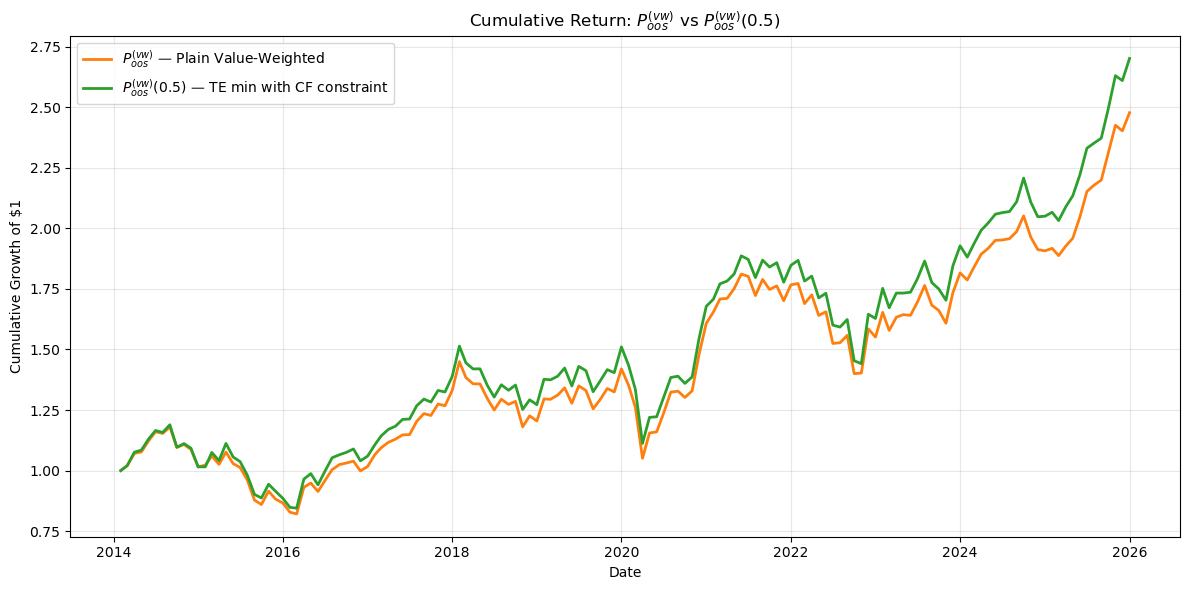

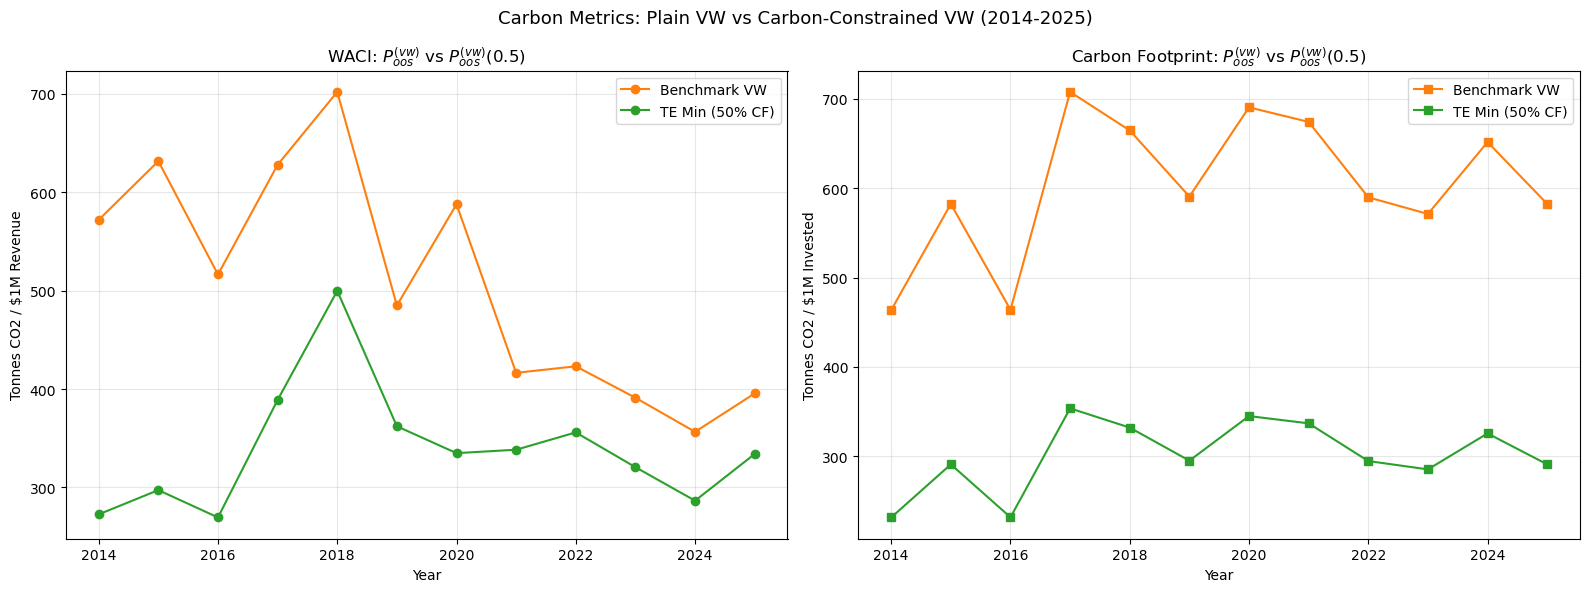

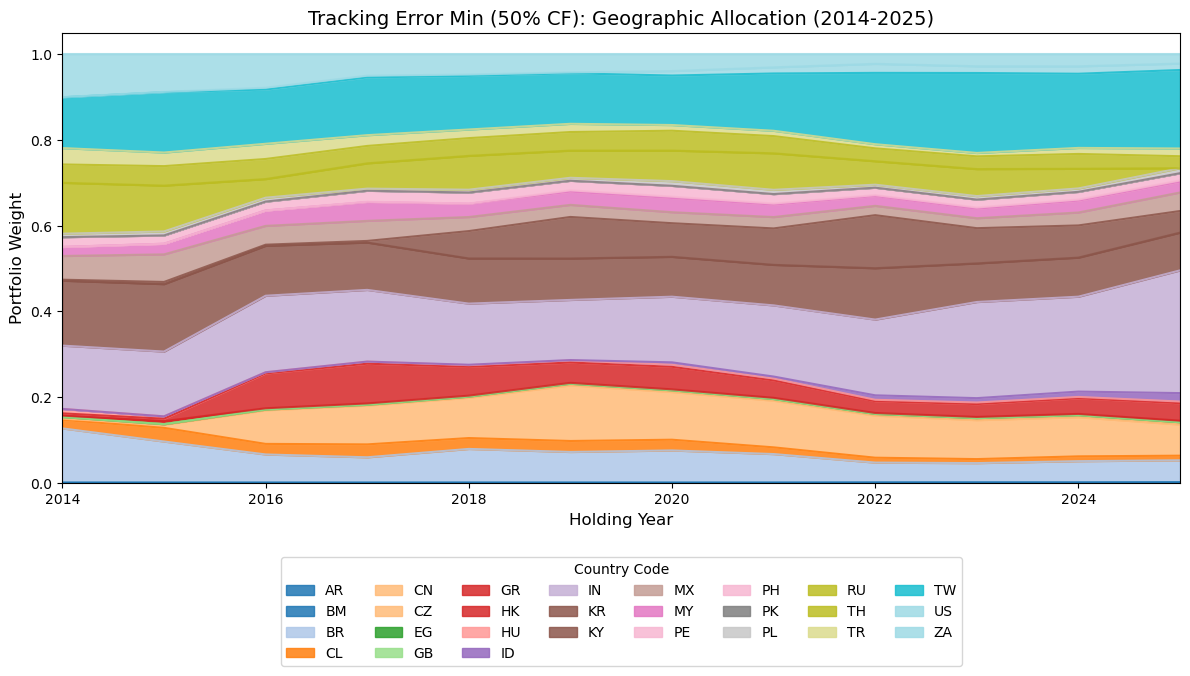

In [12]:
base_output_dir  = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
output_dir_33    = os.path.join(base_output_dir, "tracking_error_analysis")
os.makedirs(plots_output_dir, exist_ok=True)
os.makedirs(output_dir_33,    exist_ok=True)

tracking_error_weights        = {}
tracking_error_returns        = []
tracking_error_dates          = []
tracking_error_yearly_stats   = []
tracking_error_carbon_metrics = []

solver_tol = 1e-8

def regularize_covariance(Sigma, eps=1e-10):
    Sigma = np.asarray(Sigma, dtype=float)
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = Sigma + eps * np.eye(Sigma.shape[0])
    return Sigma

def tracking_error_variance(w, w_bench, Sigma):
    diff = w - w_bench
    return float(diff.T @ Sigma @ diff)

for holding_year in range(2014, 2026):
    data_year = holding_year - 1

    if holding_year not in sigma_estimates:
        print(f"Holding Year {holding_year}: covariance matrix missing, skipping.")
        continue
    if holding_year not in valid_investment_sets:
        print(f"Holding Year {holding_year}: investment set missing, skipping.")
        continue

    candidate_isins = list(valid_investment_sets[holding_year])
    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    sigma_cols      = sigma_estimates[holding_year].columns
    candidate_isins = [
        isin for isin in candidate_isins
        if isin in sigma_cols
        and isin in E_total_y.columns
        and isin in CI_y.columns
        and isin in cap_y.columns
        and isin in returns_em.columns
    ]

    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no common firms across data objects, skipping.")
        continue

    Sigma_Y = sigma_estimates[holding_year].loc[candidate_isins, candidate_isins].copy()
    E_t     = E_total_y.loc[data_year, candidate_isins].copy()
    CI_t    = CI_y.loc[data_year, candidate_isins].copy()
    Cap_t   = cap_y.loc[data_year, candidate_isins].copy()

    valid_mask        = E_t.notna() & CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins_final = E_t[valid_mask].index.tolist()

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: not enough firms with valid data, skipping.")
        continue

    Sigma_sub_df      = Sigma_Y.loc[valid_isins_final, valid_isins_final].copy()
    good_assets       = Sigma_sub_df.columns[Sigma_sub_df.notna().all()].tolist()
    valid_isins_final = good_assets

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: covariance matrix invalid after filtering, skipping.")
        continue

    Sigma_sub = regularize_covariance(
        Sigma_Y.loc[valid_isins_final, valid_isins_final].to_numpy(dtype=float)
    )
    E_sub   = E_t.loc[valid_isins_final].to_numpy(dtype=float)
    CI_sub  = CI_t.loc[valid_isins_final].to_numpy(dtype=float)
    Cap_sub = Cap_t.loc[valid_isins_final].to_numpy(dtype=float)

    w_vw        = Cap_sub / Cap_sub.sum()
    cf_firm     = E_sub / Cap_sub
    CF_vw_Y     = float(np.dot(w_vw, cf_firm))
    CF_target_Y = 0.5 * CF_vw_Y

    if float(np.min(cf_firm)) > CF_target_Y + solver_tol:
        print(f"Holding Year {holding_year}: 50% CF target is infeasible, skipping.")
        continue

    constraints = [
        {'type': 'eq',
         'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq',
         'fun': lambda w, cf=cf_firm, target=CF_target_Y: target - np.dot(w, cf)}
    ]
    bounds = [(0.0, 1.0) for _ in range(len(valid_isins_final))]

    result = minimize(
        fun=tracking_error_variance,
        x0=w_vw.copy(),
        args=(w_vw, Sigma_sub),
        method='SLSQP', bounds=bounds, constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
    )

    if not result.success:
        result = minimize(
            fun=tracking_error_variance,
            x0=np.ones(len(valid_isins_final)) / len(valid_isins_final),
            args=(w_vw, Sigma_sub),
            method='SLSQP', bounds=bounds, constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
        )

    if not result.success:
        print(f"Holding Year {holding_year}: optimization failed -> {result.message}")
        continue

    w_opt        = np.clip(result.x, 0.0, 1.0)
    w_opt        = w_opt / w_opt.sum()
    weight_sum   = float(np.sum(w_opt))
    min_weight   = float(np.min(w_opt))
    carbon_slack = float(CF_target_Y - np.dot(w_opt, cf_firm))

    if abs(weight_sum - 1.0) > 1e-6 or min_weight < -solver_tol or carbon_slack < -1e-6:
        print(f"  Holding Year {holding_year}: invalid solution "
              f"(sum={weight_sum:.8f}, min_w={min_weight:.3e}, "
              f"carbon_slack={carbon_slack:.3e}), skipping.")
        continue

    tracking_error_weights[holding_year] = pd.Series(w_opt, index=valid_isins_final)

    te_variance_Y = tracking_error_variance(w_opt, w_vw, Sigma_sub)
    te_Y          = float(np.sqrt(max(te_variance_Y, 0.0)))
    CF_te_Y       = float(np.dot(w_opt, cf_firm))
    WACI_vw_Y     = float(np.dot(w_vw, CI_sub))
    WACI_te_Y     = float(np.dot(w_opt, CI_sub))

    tracking_error_yearly_stats.append({
        'Holding_Year':          holding_year,
        'Data_Year':             data_year,
        'Number_of_Firms':       len(valid_isins_final),
        'CF_Benchmark_VW':       CF_vw_Y,
        'CF_Target_50pct':       CF_target_Y,
        'CF_TE_Portfolio':       CF_te_Y,
        'WACI_Benchmark_VW':     WACI_vw_Y,
        'WACI_TE_Portfolio':     WACI_te_Y,
        'Carbon_Slack':          carbon_slack,
        'Weight_Sum':            weight_sum,
        'Min_Weight':            min_weight,
        'Tracking_Error_ExAnte': te_Y,
        'Solver_Message':        result.message
    })

    tracking_error_carbon_metrics.append({
        'Year':       holding_year,
        'WACI_TE_05': WACI_te_Y,
        'CF_TE_05':   CF_te_Y
    })

    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31", valid_isins_final
    ].copy()

    if holding_returns.empty:
        print(f"Holding Year {holding_year}: no monthly returns available, skipping.")
        continue

    holding_returns  = holding_returns.fillna(0.0)
    current_w_te     = w_opt.copy()

    for date, row_returns in holding_returns.iterrows():
        asset_returns       = row_returns.to_numpy(dtype=float)
        te_portfolio_return = float(np.dot(current_w_te, asset_returns))

        tracking_error_returns.append(te_portfolio_return)
        tracking_error_dates.append(date)

        current_w_te = current_w_te * (1.0 + asset_returns) / (1.0 + te_portfolio_return)
        current_w_te = current_w_te / current_w_te.sum()

    print(f"  Holding Year {holding_year}: optimization successful, "
          f"CF = {CF_te_Y:.4f} <= target {CF_target_Y:.4f}")

portfolio_te_05_series       = pd.Series(tracking_error_returns, index=tracking_error_dates)
portfolio_te_05_series       = portfolio_te_05_series.loc['2014-01-01':'2025-12-31']
portfolio_te_05_series.index = portfolio_te_05_series.index.to_period('M')

benchmark_vw_33_series       = portfolio_vw_series.copy()
benchmark_vw_33_series       = benchmark_vw_33_series.loc['2014':'2025']

aligned_33 = pd.concat([
    portfolio_te_05_series.rename('TE'),
    benchmark_vw_33_series.rename('VW')
], axis=1).dropna()

portfolio_te_05_series = aligned_33['TE']
benchmark_vw_33_series = aligned_33['VW']
rf_te                  = rf_series.reindex(aligned_33.index).ffill().bfill()

print(f"P^(vw)_oos(0.5): {len(portfolio_te_05_series)} months (expected 144)")

te_excess_returns    = portfolio_te_05_series - rf_te
vw_excess_returns_33 = benchmark_vw_33_series - rf_te

te_ann_avg_return = portfolio_te_05_series.mean() * 12
te_ann_volatility = portfolio_te_05_series.std()  * np.sqrt(12)
te_ann_cum_return = (1 + portfolio_te_05_series).prod() ** (12 / len(portfolio_te_05_series)) - 1
te_sharpe_ratio   = (te_excess_returns.mean() * 12) / te_ann_volatility \
                    if te_ann_volatility != 0 else np.nan
te_min_return     = portfolio_te_05_series.min()
te_max_return     = portfolio_te_05_series.max()

vw_ann_avg_return_33 = benchmark_vw_33_series.mean() * 12
vw_ann_volatility_33 = benchmark_vw_33_series.std()  * np.sqrt(12)
vw_ann_cum_return_33 = (1 + benchmark_vw_33_series).prod() ** (12 / len(benchmark_vw_33_series)) - 1
vw_sharpe_ratio_33   = (vw_excess_returns_33.mean() * 12) / vw_ann_volatility_33 \
                       if vw_ann_volatility_33 != 0 else np.nan
vw_min_return_33     = benchmark_vw_33_series.min()
vw_max_return_33     = benchmark_vw_33_series.max()

realized_te_annualized = (portfolio_te_05_series - benchmark_vw_33_series).std() * np.sqrt(12)

comparison_stats_33 = pd.DataFrame({
    'Metric': [
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return',
        'Realized tracking error (ann.)'
    ],
    'P^(vw)_oos': [
        vw_ann_avg_return_33, vw_ann_volatility_33, vw_ann_cum_return_33,
        vw_sharpe_ratio_33,   vw_min_return_33,     vw_max_return_33, 0.0
    ],
    'P^(vw)_oos(0.5)': [
        te_ann_avg_return, te_ann_volatility, te_ann_cum_return,
        te_sharpe_ratio,   te_min_return,     te_max_return,
        realized_te_annualized
    ]
})

print("Summary Statistics: P^(vw)_oos vs P^(vw)_oos(0.5)")
display(comparison_stats_33.round(4))

df_tracking_error_diag = pd.DataFrame(tracking_error_yearly_stats).set_index('Holding_Year')
df_metrics_te          = pd.DataFrame(tracking_error_carbon_metrics).set_index('Year')
df_metrics_33          = df_metrics.join(df_metrics_te, how='left')

for col in ['WACI_VW', 'CF_VW', 'WACI_TE_05', 'CF_TE_05']:
    if col not in df_metrics_33.columns:
        df_metrics_33[col] = np.nan

print("\nOptimization Diagnostics")
display(df_tracking_error_diag.round(4))

print("\nCarbon Metrics: VW Benchmark vs TE Portfolio")
display(df_metrics_33[['WACI_VW', 'WACI_TE_05', 'CF_VW', 'CF_TE_05']].round(2))

te_plot    = portfolio_te_05_series.copy()
vw_plot_33 = benchmark_vw_33_series.copy()
te_plot.index    = te_plot.index.to_timestamp(how='end')
vw_plot_33.index = vw_plot_33.index.to_timestamp(how='end')

te_cumulative    = (1 + te_plot).cumprod()
vw_cumulative_33 = (1 + vw_plot_33).cumprod()
te_cumulative    = te_cumulative    / te_cumulative.iloc[0]
vw_cumulative_33 = vw_cumulative_33 / vw_cumulative_33.iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(vw_cumulative_33.index, vw_cumulative_33.values, linewidth=2,
         label='$P^{(vw)}_{oos}$ — Plain Value-Weighted',           color='tab:orange')
plt.plot(te_cumulative.index,    te_cumulative.values,    linewidth=2,
         label='$P^{(vw)}_{oos}(0.5)$ — TE min with CF constraint', color='tab:green')
plt.title('Cumulative Return: $P^{(vw)}_{oos}$ vs $P^{(vw)}_{oos}(0.5)$')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth of $1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_3_CumulativeReturn.png"), dpi=300)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

df_metrics_33[['WACI_VW', 'WACI_TE_05']].plot(
    ax=ax[0], marker='o', color=['tab:orange', 'tab:green'])
ax[0].set_title('WACI: $P^{(vw)}_{oos}$ vs $P^{(vw)}_{oos}(0.5)$')
ax[0].set_ylabel('Tonnes CO2 / $1M Revenue')
ax[0].legend(['Benchmark VW', 'TE Min (50% CF)'])
ax[0].grid(True, alpha=0.3)

df_metrics_33[['CF_VW', 'CF_TE_05']].plot(
    ax=ax[1], marker='s', color=['tab:orange', 'tab:green'])
ax[1].set_title('Carbon Footprint: $P^{(vw)}_{oos}$ vs $P^{(vw)}_{oos}(0.5)$')
ax[1].set_ylabel('Tonnes CO2 / $1M Invested')
ax[1].legend(['Benchmark VW', 'TE Min (50% CF)'])
ax[1].grid(True, alpha=0.3)

plt.suptitle('Carbon Metrics: Plain VW vs Carbon-Constrained VW (2014-2025)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_3_CarbonEvolution.png"), dpi=300)
plt.show()

comparison_stats_33.to_excel(
    os.path.join(output_dir_33, "Section_3_3_Summary_Statistics.xlsx"), index=False)

pd.DataFrame({
    'Tracking_Error_Portfolio_Return':     te_plot,
    'Value_Weighted_Benchmark_Return':     vw_plot_33,
    'Tracking_Error_Portfolio_Cumulative': te_cumulative,
    'Value_Weighted_Benchmark_Cumulative': vw_cumulative_33
}).to_excel(os.path.join(output_dir_33, "Section_3_3_Cumulative_Returns_TE_vs_VW.xlsx"))

df_tracking_error_diag.to_excel(
    os.path.join(output_dir_33, "Section_3_3_Optimization_Diagnostics.xlsx"))
df_metrics_33.to_excel(
    os.path.join(output_dir_33, "Section_3_3_Carbon_Metrics.xlsx"))

weights_export = []
for y, s in tracking_error_weights.items():
    tmp         = s.rename('Weight_TE_05').reset_index()
    tmp.columns = ['ISIN', 'Weight_TE_05']
    tmp.insert(0, 'Holding_Year', y)
    weights_export.append(tmp)

if len(weights_export) > 0:
    pd.concat(weights_export, ignore_index=True).to_excel(
        os.path.join(output_dir_33, "Section_3_3_Weights.xlsx"), index=False)

# Geographic allocation
weight_records_te_05 = []
for year, weights_series in tracking_error_weights.items():
    for isin, weight in weights_series.items():
        weight_records_te_05.append({'Holding_Year': year, 'ISIN': isin, 'Weight': weight})

df_weights_te_05             = pd.DataFrame(weight_records_te_05)
df_weights_te_05['Country']  = df_weights_te_05['ISIN'].str[:2]
country_alloc_te_05          = df_weights_te_05.groupby(
                                   ['Holding_Year', 'Country'])['Weight'].sum().unstack().fillna(0)

ax = country_alloc_te_05.plot(kind='area', stacked=True, figsize=(12, 7),
                               colormap='tab20', alpha=0.85)
plt.title('Tracking Error Min (50% CF): Geographic Allocation (2014-2025)', fontsize=14)
plt.ylabel('Portfolio Weight', fontsize=12)
plt.xlabel('Holding Year', fontsize=12)
plt.margins(x=0, y=0)
plt.legend(title='Country Code', loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_3_3_Geographic_Allocation.png"),
            dpi=300, bbox_inches='tight')
plt.show()

The diagnostics table reports the solver outcome, carbon slack and ex-ante tracking error for each holding year. The summary statistics table compares the tracking error portfolio against the plain value-weighted benchmark. The carbon metrics table confirms the 50% reduction is achieved each year. The cumulative return and carbon metric charts illustrate the performance and environmental impact of the two strategies over 2014-2025.

## 11. Net Zero Portfolio — Report Section 5.1

The Net Zero portfolio minimizes tracking error against the value-weighted benchmark subject to a carbon footprint constraint that tightens each year following a 10% annual reduction path anchored to the 2013 baseline:

$$CF^{(p)}_Y \leq (1 - \theta)^{Y - Y_0} \cdot CF^{(vw)}_{Y_0} \qquad \theta = 0.10, \quad Y_0 = 2013$$

The anchor $CF^{(vw)}_{Y_0}$ is computed from the 2013 investment universe using the same carbon footprint formula as in Section 10. The optimization problem is identical to Section 10 with the only difference being the target, which now follows the net zero path rather than a fixed 50% reduction.

CF_VW at Y0=2013 (anchor): 463.6123 tonnes CO2 / million USD

Net Zero CF Targets:
  2014: 417.2511  (90.0% of baseline)
  2015: 375.5260  (81.0% of baseline)
  2016: 337.9734  (72.9% of baseline)
  2017: 304.1760  (65.6% of baseline)
  2018: 273.7584  (59.0% of baseline)
  2019: 246.3826  (53.1% of baseline)
  2020: 221.7443  (47.8% of baseline)
  2021: 199.5699  (43.0% of baseline)
  2022: 179.6129  (38.7% of baseline)
  2023: 161.6516  (34.9% of baseline)
  2024: 145.4865  (31.4% of baseline)
  2025: 130.9378  (28.2% of baseline)
  Holding Year 2014: CF = 417.2511 <= NZ target 417.2511 (reduction: 10.0%)
  Holding Year 2015: CF = 375.5260 <= NZ target 375.5260 (reduction: 35.5%)
  Holding Year 2016: CF = 337.9734 <= NZ target 337.9734 (reduction: 27.2%)
  Holding Year 2017: CF = 304.1760 <= NZ target 304.1760 (reduction: 57.0%)
  Holding Year 2018: CF = 273.7584 <= NZ target 273.7584 (reduction: 58.8%)
  Holding Year 2019: CF = 246.3826 <= NZ target 246.3826 (reduction: 58.3%)
  Hol

,Metric,P^(vw)_oos,P^(vw)_oos(NZ)
0,Annualized average return,0.0822,0.0916
1,Annualized volatility,0.1557,0.1614
2,Annualized cumulative return,0.0724,0.0816
3,Sharpe ratio,0.4157,0.4595
4,Minimum monthly return,-0.1671,-0.1666
5,Maximum monthly return,0.1341,0.1433
6,Realized tracking error (ann.),0.0000,0.0189



Year-by-Year Net Zero Diagnostics


,NZ_Target,CF_VW,CF_NZ_Portfolio,Carbon_Reduction_%,WACI_VW,WACI_NZ_Portfolio,Tracking_Error_ExAnte,Carbon_Slack,N_Firms
Holding_Year,,,,,,,,,
2014,417.2511,463.6123,417.2511,10.0000,572.0070,519.1227,0.0,0.0,245
2015,375.5260,582.2943,375.5260,35.5092,631.7098,382.0399,0.0,0.0,266
2016,337.9734,463.9605,337.9734,27.1547,516.4361,381.8766,0.0,0.0,294
2017,304.1760,707.5332,304.1760,57.0089,627.9708,348.6831,0.0,0.0,332
2018,273.7584,664.4625,273.7584,58.8000,702.0969,451.7769,0.0,0.0,378
2019,246.3826,590.5780,246.3826,58.2811,484.9121,311.4193,0.0,0.0,413
2020,221.7443,690.2600,221.7443,67.8752,587.8497,247.4793,0.0,-0.0,461
2021,199.5699,673.9937,199.5699,70.3899,416.4369,242.8837,0.0,0.0,501
2022,179.6129,589.6827,179.6129,69.5408,423.0991,270.5326,0.0,0.0,538



Section 4.2 Comparison: All 3 VW Portfolios


,$P^{(vw)}_{oos}$,$P^{(vw)}_{oos}(0.5)$,$P^{(vw)}_{oos}(NZ)$
Annualized average return,0.0822,0.0901,0.0916
Annualized volatility,0.1557,0.1610,0.1614
Annualized cumulative return,0.0724,0.0800,0.0816
Sharpe ratio,0.4157,0.4512,0.4595
Minimum monthly return,-0.1671,-0.1672,-0.1666
Maximum monthly return,0.1341,0.1419,0.1433



Carbon Metrics: All Portfolios


,WACI_VW,WACI_TE_05,WACI_NZ,CF_VW,CF_TE_05,CF_NZ
Year,,,,,,
2014,572.01,272.54,519.12,463.61,231.81,417.25
2015,631.71,297.20,382.04,582.29,291.15,375.53
2016,516.44,269.40,381.88,463.96,231.98,337.97
2017,627.97,388.85,348.68,707.53,353.77,304.18
2018,702.10,499.80,451.78,664.46,332.23,273.76
2019,484.91,362.10,311.42,590.58,295.29,246.38
2020,587.85,334.78,247.48,690.26,345.13,221.74
2021,416.44,338.26,242.88,673.99,337.00,199.57
2022,423.10,355.88,270.53,589.68,294.84,179.61


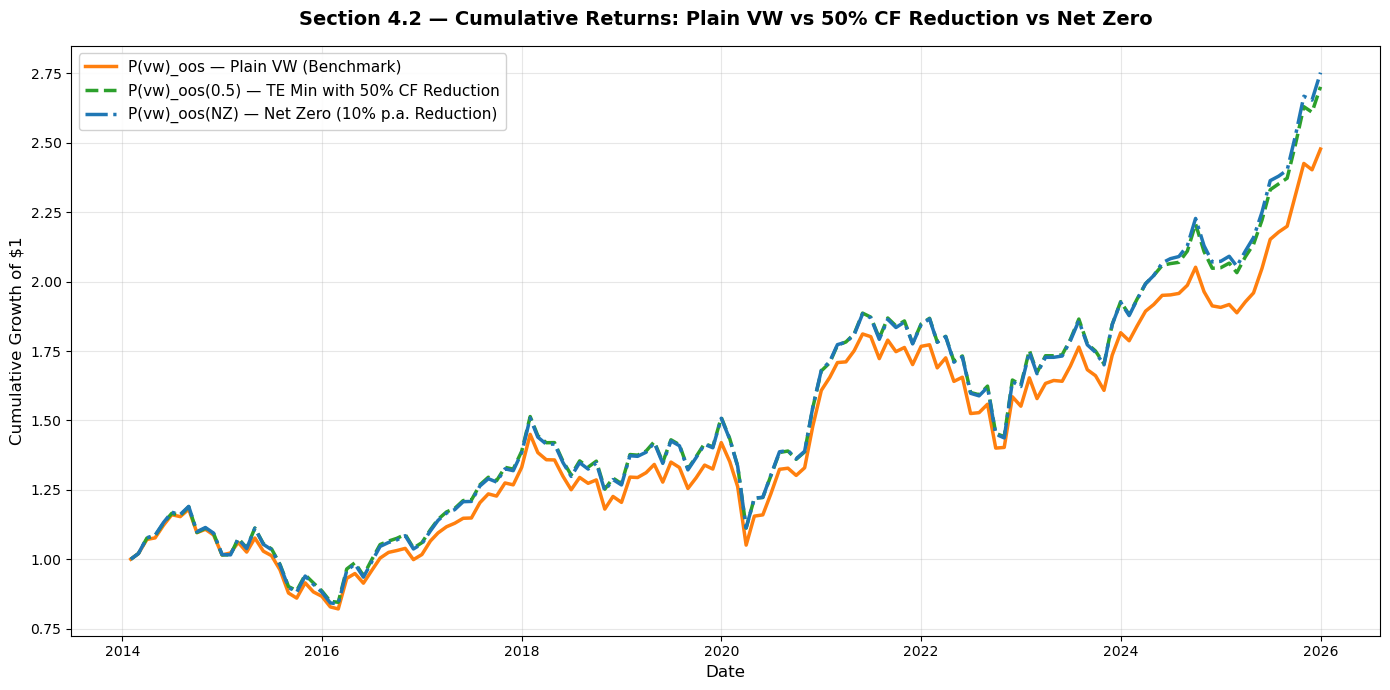

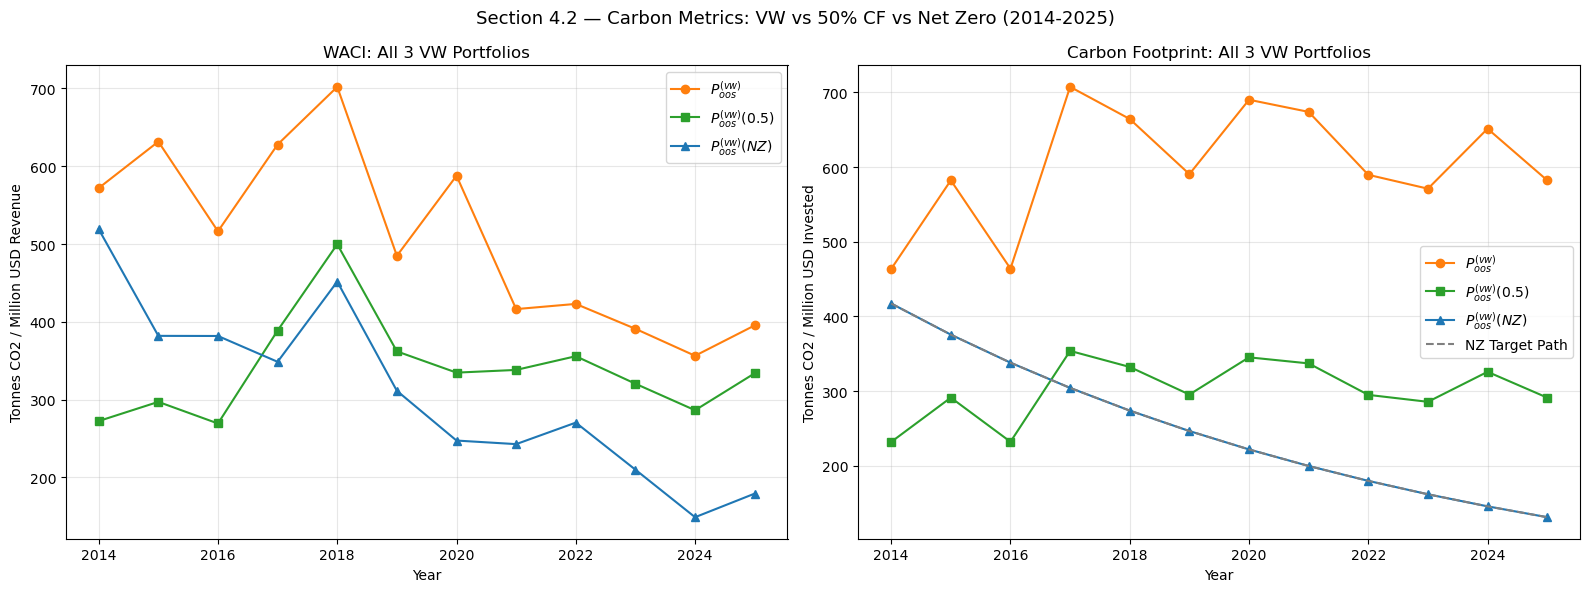

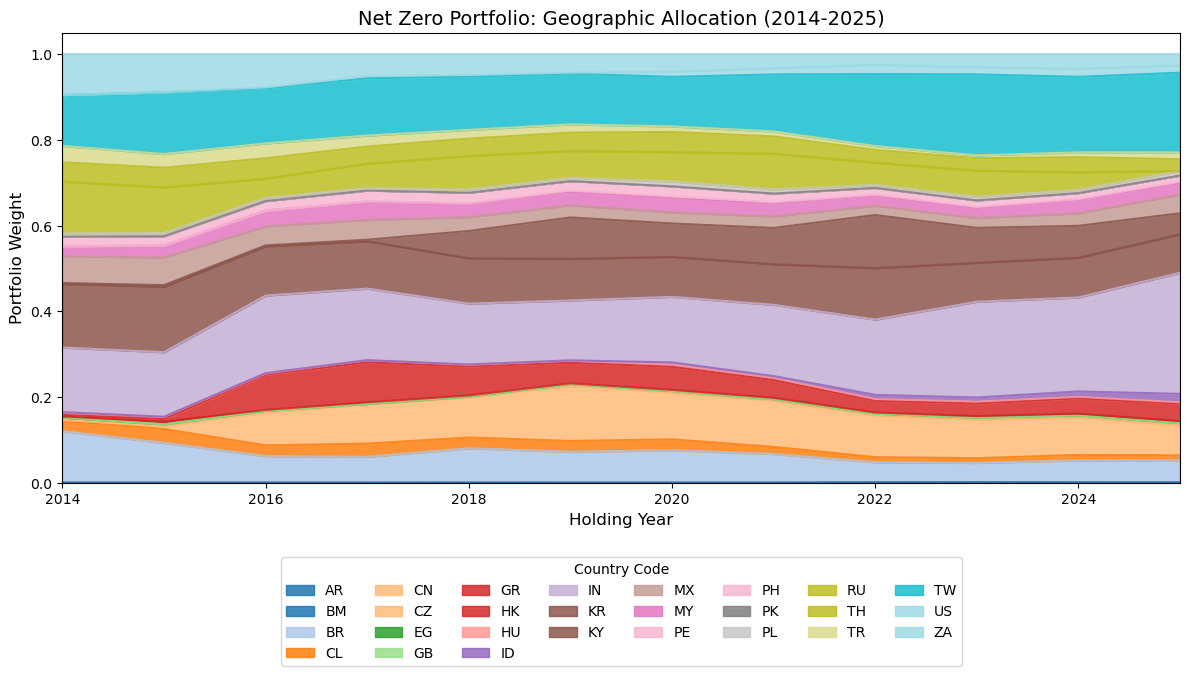


Excluded Firms: Top 5 completely dropped to reach Net Zero


,ISIN,Name,Years_Excluded
17,INE733E01010,NTPC,9
4,CNE1000002Q2,CHINA PTL.& CHM. 'H',7
5,CNE1000002R0,CHINA SHENHUA EN.CO.'H',6
23,MXP225611567,CEMEX CPO,6
12,INE047A01021,GRASIM INDUSTRIES,6



Historical Average: Top 5 Under-Weighted Firms


,Name,Baseline_VW,NZ_Weight,Shift
ISIN,,,,
INE733E01010,NTPC,0.0042,0.0007,-0.0035
KR7005490008,POSCO HOLDINGS,0.0047,0.0024,-0.0023
CNE1000002Q2,CHINA PTL.& CHM. 'H',0.0018,0.0001,-0.0017
MXP225611567,CEMEX CPO,0.0022,0.0008,-0.0014
RU0007661625,GAZPROM,0.0146,0.0132,-0.0014



Historical Average: Top 5 Over-Weighted Firms


,Name,Baseline_VW,NZ_Weight,Shift
ISIN,,,,
BRVALEACNOR0,VALE ON,0.0108,0.0119,0.0011
RU0009029540,SBERBANK OF RUSSIA,0.0120,0.0129,0.0010
INE257A01026,BHARAT HEAVY ELS.,0.0013,0.0023,0.0009
TRECOLA00011,COCA COLA ICECEK,0.0008,0.0017,0.0009
INE208A01029,ASHOK LEYLAND,0.0007,0.0015,0.0008


In [13]:
base_output_dir  = "outputs"
plots_output_dir = os.path.join(base_output_dir, "plots_carbon_metrics")
output_dir_4     = os.path.join(base_output_dir, "net_zero_analysis")
os.makedirs(plots_output_dir, exist_ok=True)
os.makedirs(output_dir_4,     exist_ok=True)

theta = 0.10
Y0    = 2013

if Y0 in valid_investment_sets and Y0 in cap_y.index and Y0 in E_total_y.index:
    nz_isins_2013 = [
        isin for isin in valid_investment_sets[2014]
        if isin in cap_y.columns
        and isin in E_total_y.columns
        and not np.isnan(cap_y.loc[Y0, isin])
        and cap_y.loc[Y0, isin] > 0
        and not np.isnan(E_total_y.loc[Y0, isin])
    ]
    cap_2013 = cap_y.loc[Y0, nz_isins_2013].values
    em_2013  = E_total_y.loc[Y0, nz_isins_2013].values
    CF_VW_Y0 = float(em_2013.sum() / cap_2013.sum())
    print(f"CF_VW at Y0=2013 (anchor): {CF_VW_Y0:.4f} tonnes CO2 / million USD")
else:
    raise RuntimeError("Cannot compute CF_VW_Y0 — check valid_investment_sets and cap_y for year 2013.")

nz_targets = {}
for holding_year in range(2014, 2026):
    exponent              = holding_year - Y0
    # Exponent is Y minus Y0, not Y minus Y0 plus 1 as in the professor guidelines.
    # This produces a 10 percent reduction in year 1 (2014), consistent with Table 14
    # of the report. The guidelines formula would yield approximately 19 percent in year
    # 1, which contradicts the stated 10 percent annual reduction path.
    nz_targets[holding_year] = (1 - theta) ** exponent * CF_VW_Y0

print("\nNet Zero CF Targets:")
for y, t in nz_targets.items():
    print(f"  {y}: {t:.4f}  ({(1-theta)**(y-Y0)*100:.1f}% of baseline)")

def regularize_covariance(Sigma, eps=1e-10):
    Sigma = np.asarray(Sigma, dtype=float)
    Sigma = 0.5 * (Sigma + Sigma.T)
    Sigma = Sigma + eps * np.eye(Sigma.shape[0])
    return Sigma

def tracking_error_variance(w, w_bench, Sigma):
    diff = w - w_bench
    return float(diff.T @ Sigma @ diff)

nz_weights        = {}
nz_returns        = []
nz_dates          = []
nz_yearly_stats   = []
nz_carbon_metrics = []

solver_tol = 1e-8

for holding_year in range(2014, 2026):
    data_year = holding_year - 1
    nz_target = nz_targets[holding_year]

    if holding_year not in sigma_estimates:
        print(f"Holding Year {holding_year}: covariance matrix missing, skipping.")
        continue
    if holding_year not in valid_investment_sets:
        print(f"Holding Year {holding_year}: investment set missing, skipping.")
        continue

    candidate_isins = list(valid_investment_sets[holding_year])
    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no eligible firms.")
        continue

    sigma_cols      = sigma_estimates[holding_year].columns
    candidate_isins = [
        isin for isin in candidate_isins
        if isin in sigma_cols
        and isin in E_total_y.columns
        and isin in CI_y.columns
        and isin in cap_y.columns
        and isin in returns_em.columns
    ]

    if len(candidate_isins) == 0:
        print(f"Holding Year {holding_year}: no common firms across data objects, skipping.")
        continue

    Sigma_Y = sigma_estimates[holding_year].loc[candidate_isins, candidate_isins].copy()
    E_t     = E_total_y.loc[data_year, candidate_isins].copy()
    CI_t    = CI_y.loc[data_year, candidate_isins].copy()
    Cap_t   = cap_y.loc[data_year, candidate_isins].copy()

    valid_mask        = E_t.notna() & CI_t.notna() & Cap_t.notna() & (Cap_t > 0)
    valid_isins_final = E_t[valid_mask].index.tolist()

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: not enough firms with valid data, skipping.")
        continue

    Sigma_sub_df      = Sigma_Y.loc[valid_isins_final, valid_isins_final].copy()
    good_assets       = Sigma_sub_df.columns[Sigma_sub_df.notna().all()].tolist()
    valid_isins_final = good_assets

    if len(valid_isins_final) < 2:
        print(f"Holding Year {holding_year}: covariance matrix invalid after filtering, skipping.")
        continue

    Sigma_sub = regularize_covariance(
        Sigma_Y.loc[valid_isins_final, valid_isins_final].to_numpy(dtype=float)
    )
    E_sub   = E_t.loc[valid_isins_final].to_numpy(dtype=float)
    CI_sub  = CI_t.loc[valid_isins_final].to_numpy(dtype=float)
    Cap_sub = Cap_t.loc[valid_isins_final].to_numpy(dtype=float)

    w_vw    = Cap_sub / Cap_sub.sum()
    cf_firm = E_sub / Cap_sub

    if float(np.min(cf_firm)) > nz_target + solver_tol:
        print(f"Holding Year {holding_year}: net zero target {nz_target:.4f} is infeasible "
              f"(min firm CF = {np.min(cf_firm):.4f}), skipping.")
        continue

    constraints = [
        {'type': 'eq',
         'fun': lambda w: np.sum(w) - 1.0},
        {'type': 'ineq',
         'fun': lambda w, cf=cf_firm, target=nz_target: target - np.dot(w, cf)}
    ]
    bounds = [(0.0, 1.0) for _ in range(len(valid_isins_final))]

    result = minimize(
        fun=tracking_error_variance, x0=w_vw.copy(),
        args=(w_vw, Sigma_sub), method='SLSQP',
        bounds=bounds, constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
    )

    if not result.success:
        result = minimize(
            fun=tracking_error_variance,
            x0=np.ones(len(valid_isins_final)) / len(valid_isins_final),
            args=(w_vw, Sigma_sub), method='SLSQP',
            bounds=bounds, constraints=constraints,
            options={'ftol': 1e-12, 'maxiter': 2000, 'disp': False}
        )

    if not result.success:
        print(f"Holding Year {holding_year}: optimization failed -> {result.message}")
        continue

    w_opt        = np.clip(result.x, 0.0, 1.0)
    w_opt        = w_opt / w_opt.sum()
    weight_sum   = float(np.sum(w_opt))
    min_weight   = float(np.min(w_opt))
    carbon_slack = float(nz_target - np.dot(w_opt, cf_firm))

    if abs(weight_sum - 1.0) > 1e-6 or min_weight < -solver_tol or carbon_slack < -1e-6:
        print(f"  Holding Year {holding_year}: invalid solution, skipping.")
        continue

    nz_weights[holding_year] = pd.Series(w_opt, index=valid_isins_final)

    te_variance_Y = tracking_error_variance(w_opt, w_vw, Sigma_sub)
    te_Y          = float(np.sqrt(max(te_variance_Y, 0.0)))
    CF_nz_Y       = float(np.dot(w_opt, cf_firm))
    CF_vw_Y       = float(np.dot(w_vw, cf_firm))
    WACI_nz_Y     = float(np.dot(w_opt, CI_sub))
    WACI_vw_Y     = float(np.dot(w_vw, CI_sub))

    nz_yearly_stats.append({
        'Holding_Year':          holding_year,
        'NZ_Target':             nz_target,
        'CF_VW':                 CF_vw_Y,
        'CF_NZ_Portfolio':       CF_nz_Y,
        'Carbon_Reduction_%':    (1 - CF_nz_Y / CF_vw_Y) * 100 if CF_vw_Y > 0 else np.nan,
        'WACI_VW':               WACI_vw_Y,
        'WACI_NZ_Portfolio':     WACI_nz_Y,
        'Tracking_Error_ExAnte': te_Y,
        'Carbon_Slack':          carbon_slack,
        'N_Firms':               len(valid_isins_final)
    })

    nz_carbon_metrics.append({
        'Year':    holding_year,
        'WACI_NZ': WACI_nz_Y,
        'CF_NZ':   CF_nz_Y
    })

    holding_returns = returns_em.loc[
        f"{holding_year}-01-01":f"{holding_year}-12-31", valid_isins_final
    ].copy()

    if holding_returns.empty:
        print(f"Holding Year {holding_year}: no monthly returns, skipping.")
        continue

    holding_returns = holding_returns.fillna(0.0)
    current_w_nz    = w_opt.copy()

    for date, row_returns in holding_returns.iterrows():
        asset_returns       = row_returns.to_numpy(dtype=float)
        nz_portfolio_return = float(np.dot(current_w_nz, asset_returns))

        nz_returns.append(nz_portfolio_return)
        nz_dates.append(date)

        current_w_nz = current_w_nz * (1.0 + asset_returns) / (1.0 + nz_portfolio_return)
        current_w_nz = current_w_nz / current_w_nz.sum()

    print(f"  Holding Year {holding_year}: CF = {CF_nz_Y:.4f} "
          f"<= NZ target {nz_target:.4f} "
          f"(reduction: {(1-CF_nz_Y/CF_vw_Y)*100:.1f}%)")

portfolio_nz_series       = pd.Series(nz_returns, index=nz_dates)
portfolio_nz_series       = portfolio_nz_series.loc['2014-01-01':'2025-12-31']
portfolio_nz_series.index = portfolio_nz_series.index.to_period('M')

benchmark_vw_nz = portfolio_vw_series.copy().loc['2014':'2025']

aligned_nz = pd.concat([
    portfolio_nz_series.rename('NZ'),
    benchmark_vw_nz.rename('VW')
], axis=1).dropna()

portfolio_nz_series = aligned_nz['NZ']
benchmark_vw_nz     = aligned_nz['VW']
rf_nz               = rf_series.reindex(aligned_nz.index).ffill().bfill()

print(f"P^(vw)_oos(NZ): {len(portfolio_nz_series)} months (expected 144)")

nz_excess = portfolio_nz_series - rf_nz
vw_excess = benchmark_vw_nz     - rf_nz

nz_ann_avg_return = portfolio_nz_series.mean() * 12
nz_ann_volatility = portfolio_nz_series.std()  * np.sqrt(12)
nz_ann_cum_return = (1 + portfolio_nz_series).prod() ** (12 / len(portfolio_nz_series)) - 1
nz_sharpe_ratio   = (nz_excess.mean() * 12) / nz_ann_volatility \
                    if nz_ann_volatility != 0 else np.nan
nz_min_return     = portfolio_nz_series.min()
nz_max_return     = portfolio_nz_series.max()

vw_ann_avg_return = benchmark_vw_nz.mean() * 12
vw_ann_volatility = benchmark_vw_nz.std()  * np.sqrt(12)
vw_ann_cum_return = (1 + benchmark_vw_nz).prod() ** (12 / len(benchmark_vw_nz)) - 1
vw_sharpe_ratio   = (vw_excess.mean() * 12) / vw_ann_volatility \
                    if vw_ann_volatility != 0 else np.nan
vw_min_return     = benchmark_vw_nz.min()
vw_max_return     = benchmark_vw_nz.max()

nz_realized_te = (portfolio_nz_series - benchmark_vw_nz).std() * np.sqrt(12)

comparison_stats_nz = pd.DataFrame({
    'Metric': [
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return',
        'Realized tracking error (ann.)'
    ],
    'P^(vw)_oos': [
        vw_ann_avg_return, vw_ann_volatility, vw_ann_cum_return,
        vw_sharpe_ratio,   vw_min_return,     vw_max_return, 0.0
    ],
    'P^(vw)_oos(NZ)': [
        nz_ann_avg_return, nz_ann_volatility, nz_ann_cum_return,
        nz_sharpe_ratio,   nz_min_return,     nz_max_return,
        nz_realized_te
    ]
})

print("Section 4.1 Summary Statistics: P^(vw)_oos vs P^(vw)_oos(NZ)")
display(comparison_stats_nz.round(4))

df_nz_yearly = pd.DataFrame(nz_yearly_stats).set_index('Holding_Year')
print("\nYear-by-Year Net Zero Diagnostics")
display(df_nz_yearly.round(4))

aligned_42 = pd.concat([
    benchmark_vw_nz.rename('VW'),
    portfolio_te_05_series.rename('TE05'),
    portfolio_nz_series.rename('NZ')
], axis=1).dropna()

vw_42   = aligned_42['VW']
te05_42 = aligned_42['TE05']
nz_42   = aligned_42['NZ']
rf_42   = rf_series.reindex(aligned_42.index).ffill().bfill()

def compute_stats(series, rf, label):
    excess  = series - rf
    ann_vol = series.std() * np.sqrt(12)
    sharpe  = (excess.mean() * 12) / ann_vol if ann_vol > 0 else np.nan
    return pd.Series([
        series.mean() * 12,
        ann_vol,
        (1 + series).prod() ** (12 / len(series)) - 1,
        sharpe,
        series.min(),
        series.max()
    ], index=[
        'Annualized average return',
        'Annualized volatility',
        'Annualized cumulative return',
        'Sharpe ratio',
        'Minimum monthly return',
        'Maximum monthly return'
    ], name=label)

comparison_42 = pd.concat([
    compute_stats(vw_42,   rf_42, '$P^{(vw)}_{oos}$'),
    compute_stats(te05_42, rf_42, '$P^{(vw)}_{oos}(0.5)$'),
    compute_stats(nz_42,   rf_42, '$P^{(vw)}_{oos}(NZ)$')
], axis=1)

print("\nSection 4.2 Comparison: All 3 VW Portfolios")
display(comparison_42.round(4))

df_nz_carbon   = pd.DataFrame(nz_carbon_metrics).set_index('Year')
df_metrics_all = df_metrics.join(df_metrics_te, how='left').join(df_nz_carbon, how='left')

for col in ['WACI_VW', 'CF_VW', 'WACI_TE_05', 'CF_TE_05', 'WACI_NZ', 'CF_NZ']:
    if col not in df_metrics_all.columns:
        df_metrics_all[col] = np.nan

print("\nCarbon Metrics: All Portfolios")
display(df_metrics_all[['WACI_VW', 'WACI_TE_05', 'WACI_NZ',
                          'CF_VW',   'CF_TE_05',   'CF_NZ']].round(2))

vw_42_plot   = vw_42.copy()
te05_42_plot = te05_42.copy()
nz_42_plot   = nz_42.copy()

vw_42_plot.index   = vw_42_plot.index.to_timestamp(how='end')
te05_42_plot.index = te05_42_plot.index.to_timestamp(how='end')
nz_42_plot.index   = nz_42_plot.index.to_timestamp(how='end')

vw_42_cum   = (1 + vw_42_plot).cumprod()   / (1 + vw_42_plot).cumprod().iloc[0]
te05_42_cum = (1 + te05_42_plot).cumprod() / (1 + te05_42_plot).cumprod().iloc[0]
nz_42_cum   = (1 + nz_42_plot).cumprod()   / (1 + nz_42_plot).cumprod().iloc[0]

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(vw_42_cum.index,   vw_42_cum.values,   linewidth=2.5, color='tab:orange',
        linestyle='solid',   label='P(vw)_oos — Plain VW (Benchmark)')
ax.plot(te05_42_cum.index, te05_42_cum.values, linewidth=2.5, color='tab:green',
        linestyle='dashed',  label='P(vw)_oos(0.5) — TE Min with 50% CF Reduction')
ax.plot(nz_42_cum.index,   nz_42_cum.values,   linewidth=2.5, color='tab:blue',
        linestyle='dashdot', label='P(vw)_oos(NZ) — Net Zero (10% p.a. Reduction)')
ax.set_title('Section 4.2 — Cumulative Returns: Plain VW vs 50% CF Reduction vs Net Zero',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Growth of $1', fontsize=12)
ax.legend(fontsize=11, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_4_2_AllVW_CumulativeReturn.png"), dpi=300)
plt.show()

years_plot = sorted(df_metrics_all.index.tolist())
fig, axes  = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(years_plot, df_metrics_all.loc[years_plot, 'WACI_VW'].values,
             marker='o', color='tab:orange', label='$P^{(vw)}_{oos}$')
axes[0].plot(years_plot, [df_metrics_all.loc[y, 'WACI_TE_05']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='s', color='tab:green',  label='$P^{(vw)}_{oos}(0.5)$')
axes[0].plot(years_plot, [df_metrics_all.loc[y, 'WACI_NZ']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='^', color='tab:blue',   label='$P^{(vw)}_{oos}(NZ)$')
axes[0].set_title('WACI: All 3 VW Portfolios')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Tonnes CO2 / Million USD Revenue')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(years_plot, df_metrics_all.loc[years_plot, 'CF_VW'].values,
             marker='o', color='tab:orange', label='$P^{(vw)}_{oos}$')
axes[1].plot(years_plot, [df_metrics_all.loc[y, 'CF_TE_05']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='s', color='tab:green',  label='$P^{(vw)}_{oos}(0.5)$')
axes[1].plot(years_plot, [df_metrics_all.loc[y, 'CF_NZ']
             if y in df_metrics_all.index else np.nan for y in years_plot],
             marker='^', color='tab:blue',   label='$P^{(vw)}_{oos}(NZ)$')

nz_target_values = [(1 - theta) ** (y - Y0) * CF_VW_Y0 for y in years_plot]
axes[1].plot(years_plot, nz_target_values, linestyle='--', color='gray',
             linewidth=1.5, label='NZ Target Path')
axes[1].set_title('Carbon Footprint: All 3 VW Portfolios')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Tonnes CO2 / Million USD Invested')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Section 4.2 — Carbon Metrics: VW vs 50% CF vs Net Zero (2014-2025)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_4_2_AllVW_CarbonMetrics.png"), dpi=300)
plt.show()

comparison_stats_nz.to_excel(
    os.path.join(output_dir_4, "Section_4_1_Summary_Statistics_NZ.xlsx"), index=False)
comparison_42.to_excel(
    os.path.join(output_dir_4, "Section_4_2_Comparison_All_VW_Portfolios.xlsx"))
df_nz_yearly.to_excel(
    os.path.join(output_dir_4, "Section_4_1_NZ_Yearly_Diagnostics.xlsx"))
df_metrics_all.to_excel(
    os.path.join(output_dir_4, "Section_4_Carbon_Metrics_All_Portfolios.xlsx"))

weights_nz_export = []
for y, s in nz_weights.items():
    tmp         = s.rename('Weight_NZ').reset_index()
    tmp.columns = ['ISIN', 'Weight_NZ']
    tmp.insert(0, 'Holding_Year', y)
    weights_nz_export.append(tmp)

if len(weights_nz_export) > 0:
    pd.concat(weights_nz_export, ignore_index=True).to_excel(
        os.path.join(output_dir_4, "Section_4_1_NZ_Weights.xlsx"), index=False)

# Geographic allocation
weight_records_nz = []
for year, weights_series in nz_weights.items():
    for isin, weight in weights_series.items():
        weight_records_nz.append({'Holding_Year': year, 'ISIN': isin, 'Weight': weight})

df_weights_nz            = pd.DataFrame(weight_records_nz)
df_weights_nz['Country'] = df_weights_nz['ISIN'].str[:2]
country_alloc_nz         = df_weights_nz.groupby(
                               ['Holding_Year', 'Country'])['Weight'].sum().unstack().fillna(0)

ax = country_alloc_nz.plot(kind='area', stacked=True, figsize=(12, 7),
                            colormap='tab20', alpha=0.85)
plt.title('Net Zero Portfolio: Geographic Allocation (2014-2025)', fontsize=14)
plt.ylabel('Portfolio Weight', fontsize=12)
plt.xlabel('Holding Year', fontsize=12)
plt.margins(x=0, y=0)
plt.legend(title='Country Code', loc='upper center',
           bbox_to_anchor=(0.5, -0.15), ncol=8)
plt.tight_layout()
plt.savefig(os.path.join(plots_output_dir, "Strategy_4_Geographic_Allocation.png"),
            dpi=300, bbox_inches='tight')
plt.show()

# Composition shifts
yearly_shifts_nz = []
name_mapping     = globals().get('isin_to_name', {})

for holding_year in range(2014, 2026):
    if holding_year not in nz_weights:
        continue
    data_year   = holding_year - 1
    w_nz        = nz_weights[holding_year]
    valid_isins = w_nz.index.tolist()
    caps        = cap_y.loc[data_year, valid_isins]
    w_vw        = caps / caps.sum()

    year_shift_df = pd.DataFrame({
        'Year':         holding_year,
        'ISIN':         valid_isins,
        'Name':         [name_mapping.get(i, i) for i in valid_isins],
        'Weight_VW':    w_vw.values,
        'Weight_NZ':    w_nz.values,
        'Delta_Weight': w_nz.values - w_vw.values
    })
    yearly_shifts_nz.append(year_shift_df)

df_yearly_shifts_nz = pd.concat(yearly_shifts_nz, ignore_index=True)

excluded_mask_nz  = (df_yearly_shifts_nz['Weight_VW'] > 0.001) & \
                    (df_yearly_shifts_nz['Weight_NZ'] < 0.00001)
excluded_firms_nz = df_yearly_shifts_nz[excluded_mask_nz]
most_excluded_nz  = excluded_firms_nz.groupby(['ISIN', 'Name']).size().reset_index(
                        name='Years_Excluded')
most_excluded_nz  = most_excluded_nz.sort_values(
                        by='Years_Excluded', ascending=False).head(5)

print("\nExcluded Firms: Top 5 completely dropped to reach Net Zero")
display(most_excluded_nz)

num_years         = 12
avg_weights_vw_nz = df_yearly_shifts_nz.groupby('ISIN')['Weight_VW'].sum() / num_years
avg_weights_nz_nz = df_yearly_shifts_nz.groupby('ISIN')['Weight_NZ'].sum() / num_years

weight_diff_nz = pd.DataFrame({
    'Baseline_VW': avg_weights_vw_nz,
    'NZ_Weight':   avg_weights_nz_nz,
    'Shift':       avg_weights_nz_nz - avg_weights_vw_nz
}).fillna(0)
weight_diff_nz['Name'] = [name_mapping.get(i, i) for i in weight_diff_nz.index]

top_underweighted_nz = weight_diff_nz.sort_values(by='Shift').head(5)
top_overweighted_nz  = weight_diff_nz.sort_values(by='Shift', ascending=False).head(5)

print("\nHistorical Average: Top 5 Under-Weighted Firms")
display(top_underweighted_nz[['Name', 'Baseline_VW', 'NZ_Weight', 'Shift']].round(4))

print("\nHistorical Average: Top 5 Over-Weighted Firms")
display(top_overweighted_nz[['Name', 'Baseline_VW', 'NZ_Weight', 'Shift']].round(4))

df_yearly_shifts_nz.to_excel(
    os.path.join(output_dir_4, "Section_4_Composition_Shifts.xlsx"), index=False)

The summary statistics table compares the Net Zero portfolio against the plain value-weighted benchmark across return and risk metrics. The comparison table then places all three value-weighted strategies side by side — plain VW, 50% CF constrained and Net Zero. The carbon footprint chart includes the theoretical net zero target path in grey to verify that the constraint is respected each year. The composition tables identify which firms are systematically excluded or reweighted to satisfy the increasingly tight annual carbon targets.

## 12. Geographic Allocation Comparisons — Report Section 3.2 and Section 5.2

All country allocations are aligned to a common set of country codes before plotting so that colors are consistent across strategies. Three side-by-side comparisons are produced: the baseline minimum variance portfolio against the value-weighted benchmark, the two carbon-constrained minimum variance strategies against each other, and the tracking error portfolio against the net zero trajectory.

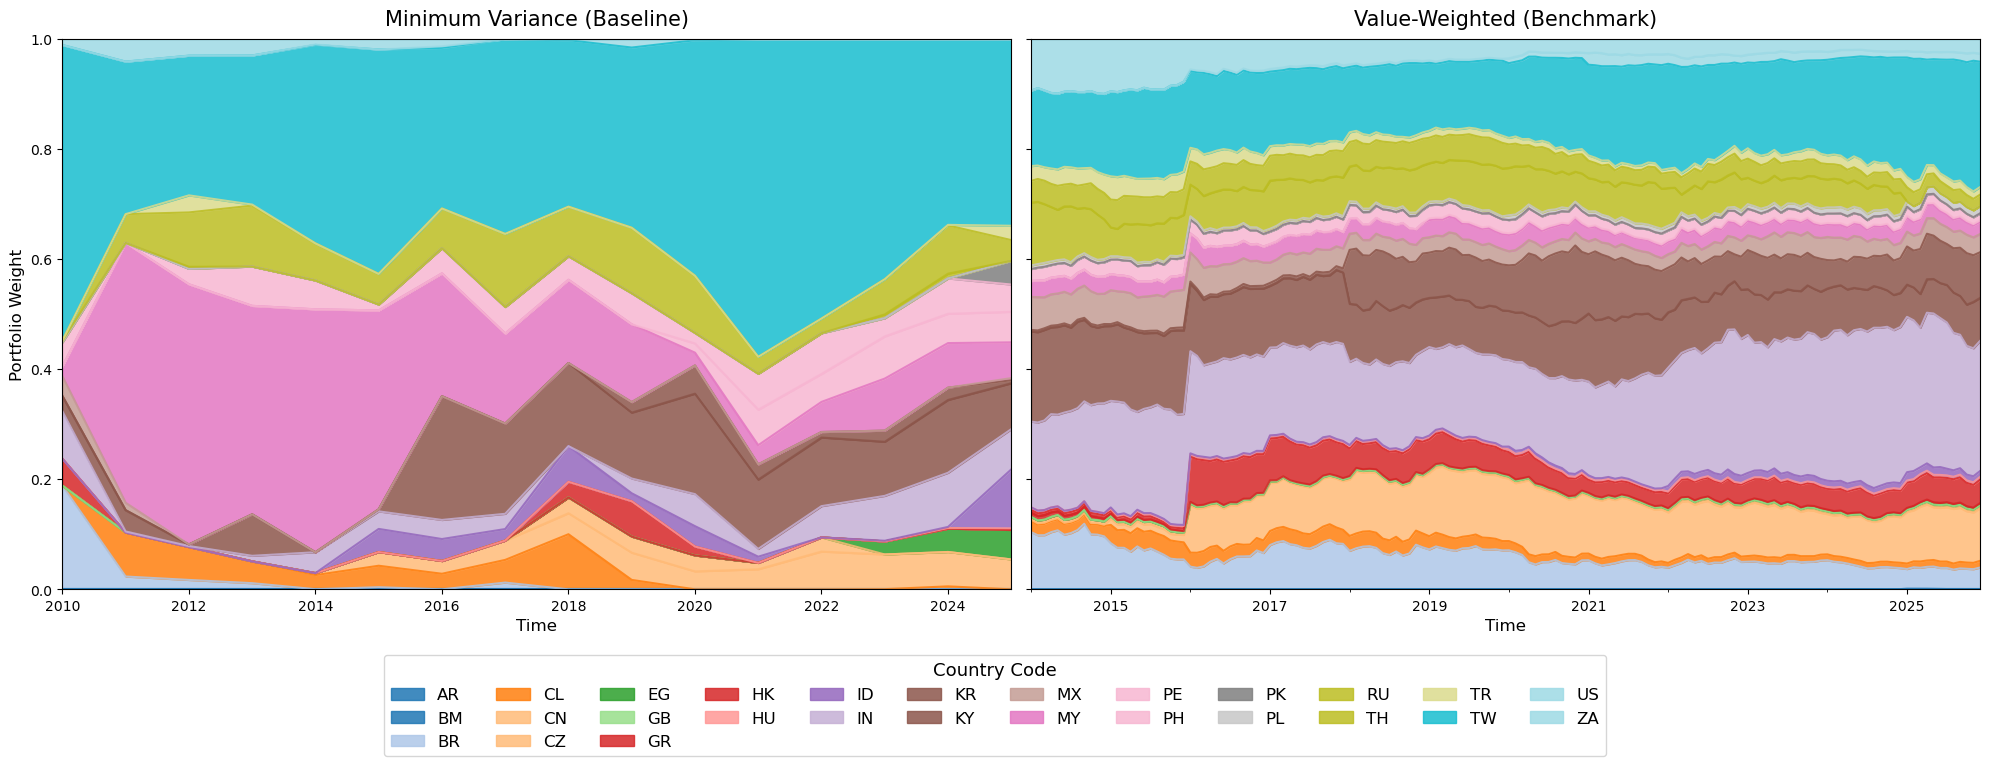

Saved: Comparison_1_MV_vs_VW_Geographic.png


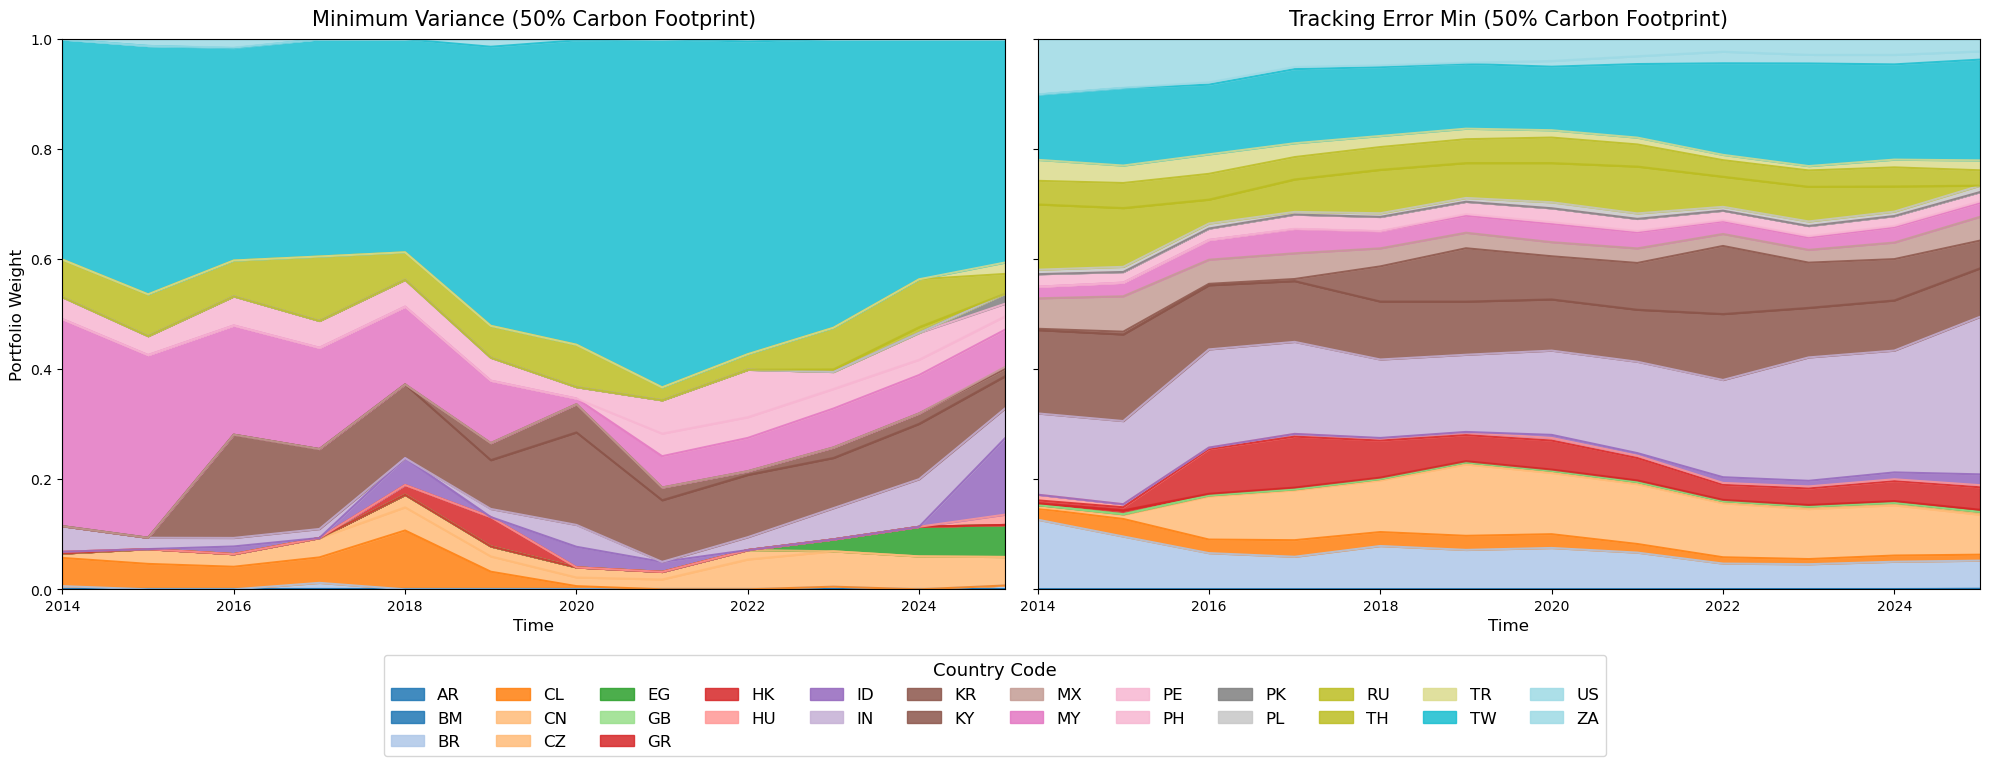

Saved: Comparison_2_MV50_vs_TE50_Geographic.png


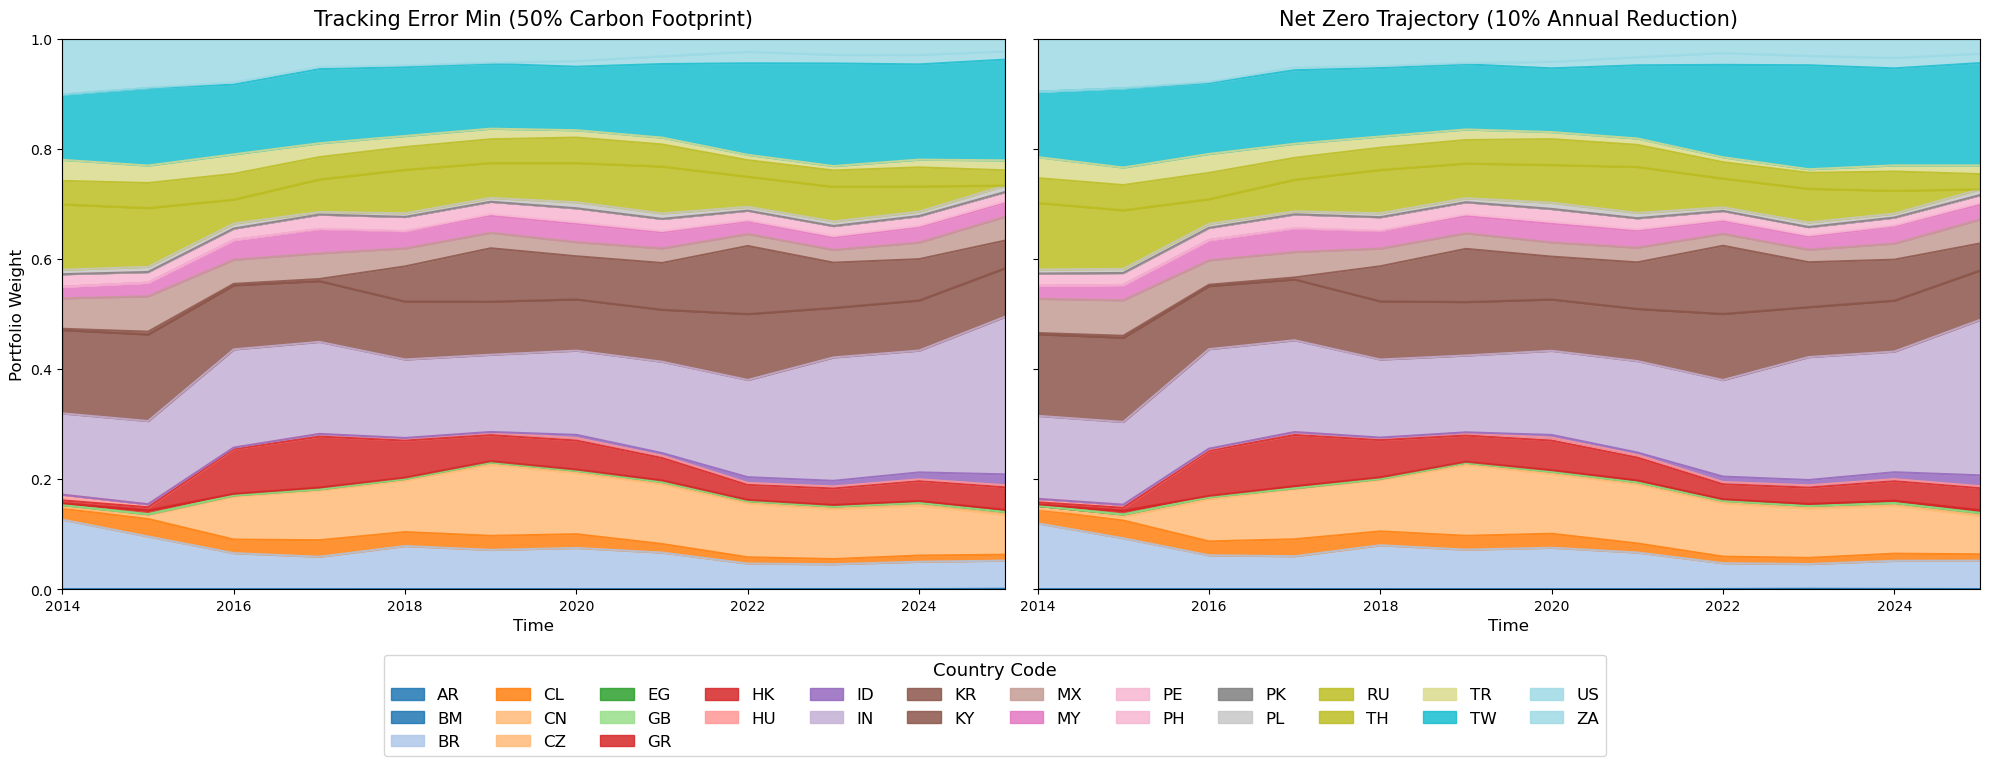

Saved: Comparison_3_TE50_vs_NetZero_Geographic.png
All side-by-side comparisons successfully generated.


In [14]:
plots_output_dir = os.path.join("outputs", "plots_carbon_metrics")
os.makedirs(plots_output_dir, exist_ok=True)

all_countries = set()
for df in [country_alloc, df_vw_alloc, country_alloc_05, country_alloc_te_05, country_alloc_nz]:
    all_countries.update(df.columns)
all_countries = sorted(list(all_countries))

def align_countries(df, all_cols):
    return df.reindex(columns=all_cols, fill_value=0.0)

alloc_mv_aligned   = align_countries(country_alloc,         all_countries)
alloc_vw_aligned   = align_countries(df_vw_alloc,           all_countries)
alloc_mv05_aligned = align_countries(country_alloc_05,      all_countries)
alloc_te05_aligned = align_countries(country_alloc_te_05,   all_countries)
alloc_nz_aligned   = align_countries(country_alloc_nz,      all_countries)

def plot_side_by_side(df1, title1, df2, title2, filename):
    fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

    df1.plot(kind='area', stacked=True, ax=axes[0],
             colormap='tab20', alpha=0.85, legend=False)
    axes[0].set_title(title1, fontsize=15, pad=10)
    axes[0].set_ylabel('Portfolio Weight', fontsize=12)
    axes[0].set_xlabel('Time', fontsize=12)
    axes[0].margins(x=0, y=0)

    df2.plot(kind='area', stacked=True, ax=axes[1],
             colormap='tab20', alpha=0.85, legend=False)
    axes[1].set_title(title2, fontsize=15, pad=10)
    axes[1].set_xlabel('Time', fontsize=12)
    axes[1].margins(x=0, y=0)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Country Code', loc='lower center',
               bbox_to_anchor=(0.5, -0.10), ncol=12, fontsize=12, title_fontsize=13)

    plt.tight_layout()
    fig.subplots_adjust(bottom=0.15)

    filepath = os.path.join(plots_output_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

plot_side_by_side(
    alloc_mv_aligned,   'Minimum Variance (Baseline)',
    alloc_vw_aligned,   'Value-Weighted (Benchmark)',
    'Comparison_1_MV_vs_VW_Geographic.png'
)

plot_side_by_side(
    alloc_mv05_aligned, 'Minimum Variance (50% Carbon Footprint)',
    alloc_te05_aligned, 'Tracking Error Min (50% Carbon Footprint)',
    'Comparison_2_MV50_vs_TE50_Geographic.png'
)

plot_side_by_side(
    alloc_te05_aligned, 'Tracking Error Min (50% Carbon Footprint)',
    alloc_nz_aligned,   'Net Zero Trajectory (10% Annual Reduction)',
    'Comparison_3_TE50_vs_NetZero_Geographic.png'
)

print("All side-by-side comparisons successfully generated.")

Each chart shows the evolution of geographic allocation from 2014 to 2025 for two strategies simultaneously, allowing a direct visual comparison of how the carbon constraints shift country-level exposure relative to the unconstrained benchmarks.